In [15]:
import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.1.1


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

qiskit_runtime_service._discover_backends_from_instance:WARNING:2025-08-10 17:22:00,690: Invalid instance crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::


{'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'SdLPpLQVGu6qIZFCVHM_NlXgLclPl6ChHutUjeeZcXxq',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/41b8ca65ee7f46799ee46a27b8d24ebd:ac605fda-c1f5-4a59-8c3e-8a74c6e7abcd::',
  'verify': True,
  'private_endpoint': False}}

In [ ]:
# Essential libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io
from PIL import Image
import random

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution
from qiskit.quantum_info import Statevector, Pauli, Operator, SparsePauliOp

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

In [19]:
def to_even(a1, a2):
    return (a1 + a2) % 2

def to_odd(b1, b2):
    return (b1 + b2 + 1) % 2

In [20]:
print(to_even(0, 0))  # Should return 0
print(to_even(0, 1))  # Should return 1
print(to_even(1, 0))  # Should return 1
print(to_even(1, 1))  # Should return 0

print(to_odd(0, 0))  # Should return 1
print(to_odd(0, 1))  # Should return 0
print(to_odd(1, 0))  # Should return 0
print(to_odd(1, 1))  # Should return 1

0
1
1
0
1
0
0
1


In [ ]:
def create_magic_circuit(assigned_a: int, assigned_b: int) -> QuantumCircuit:
    """
    Create a quantum circuit for the DIQKD magic square protocol.

    Args:
        assigned_a (int): Alice's assigned row (0, 1, or 2).
        assigned_b (int): Bob's assigned column (0, 1, or 2).
    
    Returns:
        QuantumCircuit: The quantum circuit implementing the magic square protocol in accordance with assigned row/col.
    """
    if assigned_a not in range(3) or assigned_b not in range(3):
        raise ValueError("assigned_a and assigned_b must be between 0 and 2.")

    # Create separate registers
    main_qubits = QuantumRegister(4, 'main')
    main_cbits = ClassicalRegister(4, 'main_c')
    ancilla_qubits = QuantumRegister(4, 'ancilla')
    ancilla_cbits = ClassicalRegister(4, 'ancilla_c')
    
    qc = QuantumCircuit(main_qubits, ancilla_qubits, main_cbits, ancilla_cbits, 
                        name=f'magic_circuit_({assigned_a}, {assigned_b})')

    # ∣Φ+⟩ ⊗ ∣Φ+⟩ initial state
    qc.h(main_qubits[0])
    qc.cx(main_qubits[0], main_qubits[1])
    qc.h(main_qubits[2])
    qc.cx(main_qubits[2], main_qubits[3])

    qc.barrier()
    
    # Row 1: Alice measures q3 in the X basis, q1 in the Z basis
    if assigned_a == 0:
        qc.h(main_qubits[3])
    
    # Row 2: Alice measures q3 in the Z basis, q1 in the X basis
    if assigned_a == 1:
        qc.h(main_qubits[1])

    # Col 1: Bob measures q2 in the Z basis, q0 in the Z basis
    if assigned_b == 0:
        pass

    # Col 2: Bob measures q2 in the X basis, q0 in the X basis
    if assigned_b == 1:
        qc.h(main_qubits[2])
        qc.h(main_qubits[0])

    # Row 3: Alice measures ancilla; Measure in Z ⊗ Z, Measure in X ⊗ X
    if assigned_a == 2:
        # Measure in Z ⊗ Z
        qc.barrier()
        qc.cx(main_qubits[3], ancilla_qubits[0])
        qc.cx(main_qubits[1], ancilla_qubits[0])
        qc.barrier()
        # Measure in X ⊗ X
        qc.h(main_qubits[3])
        qc.h(main_qubits[1])
        qc.cx(main_qubits[3], ancilla_qubits[1])
        qc.cx(main_qubits[1], ancilla_qubits[1])
        qc.h(main_qubits[3])
        qc.h(main_qubits[1])
        qc.barrier()

    # Col 3: Bob measures ancilla; Measure in X ⊗ Z, Measure in Z ⊗ X
    if assigned_b == 2:
        # Measure in X ⊗ Z
        qc.barrier()
        qc.h(main_qubits[2])
        qc.cx(main_qubits[2], ancilla_qubits[2])
        qc.cx(main_qubits[0], ancilla_qubits[2])
        qc.h(main_qubits[2])
        qc.barrier()
        # Measure in Z ⊗ X
        qc.h(main_qubits[0])
        qc.cx(main_qubits[2], ancilla_qubits[3])
        qc.cx(main_qubits[0], ancilla_qubits[3])
        qc.h(main_qubits[0])
        qc.barrier()
    qc.barrier()
    
    # Measure main qubits
    qc.measure(main_qubits, main_cbits)
    # Measure ancilla qubits
    qc.measure(ancilla_qubits, ancilla_cbits)

    return qc

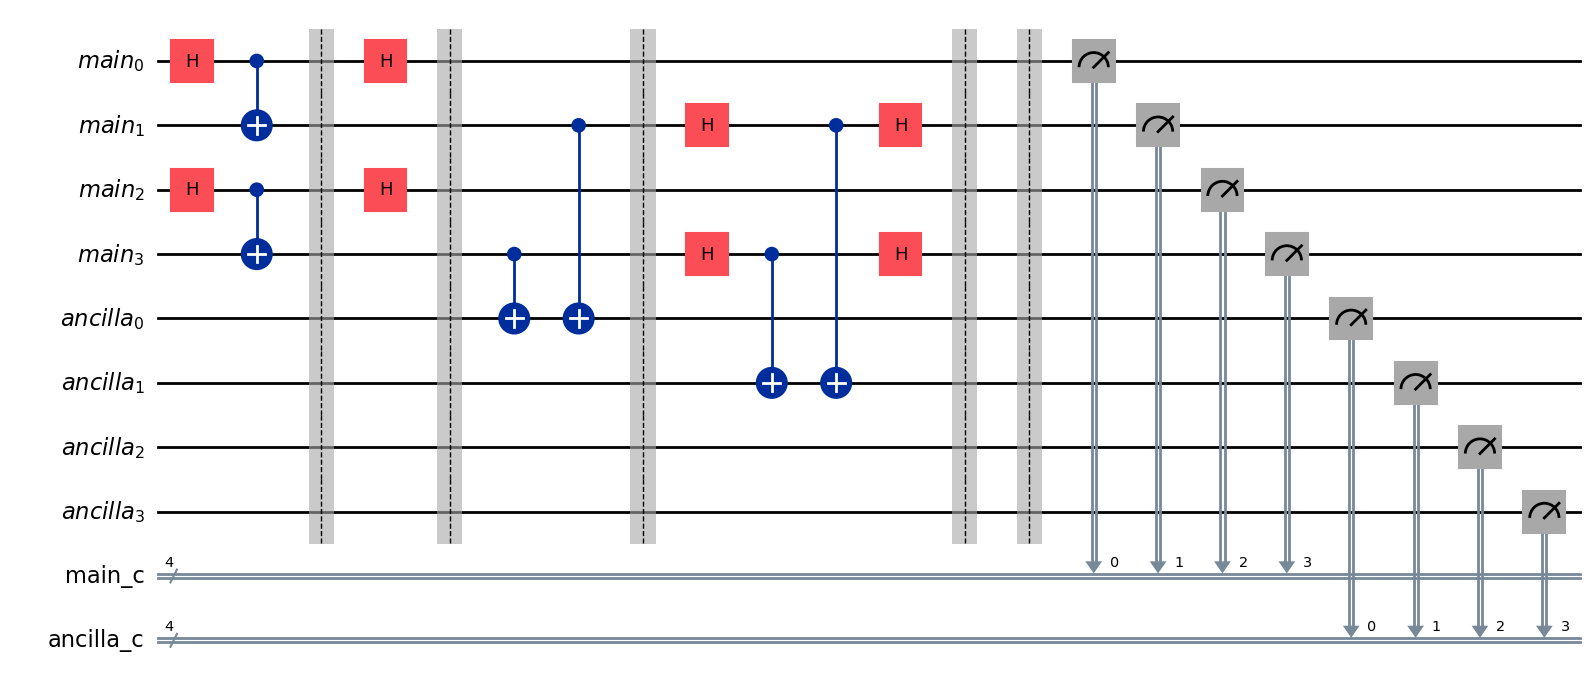

In [23]:
create_magic_circuit(2, 1).draw('mpl')

Input pair 0: (0, 0)


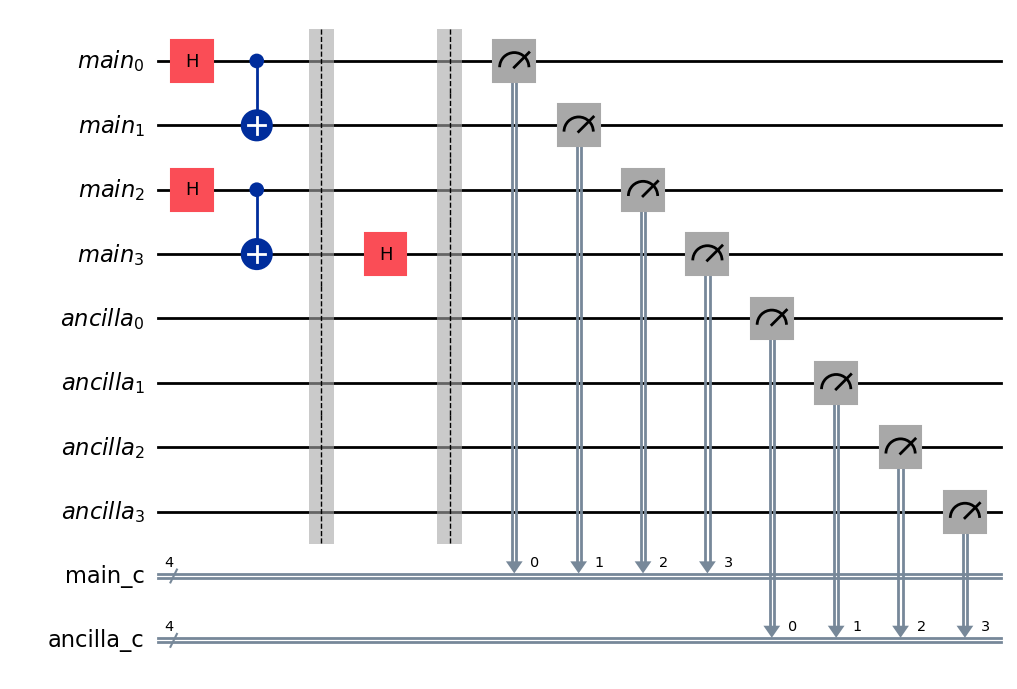

Input pair 1: (0, 1)


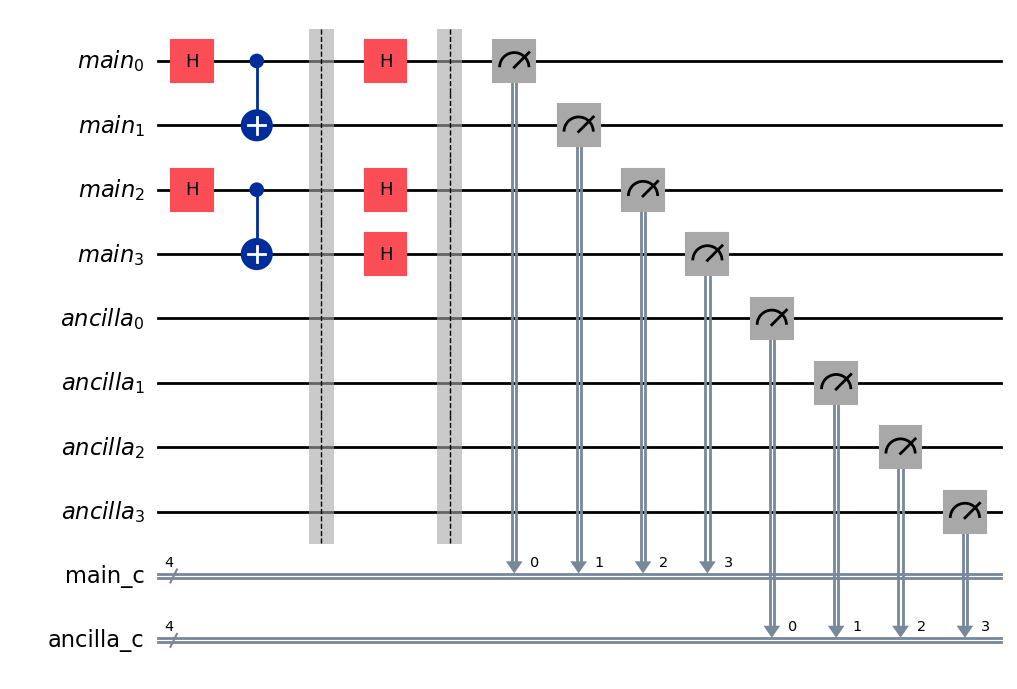

Input pair 2: (0, 2)


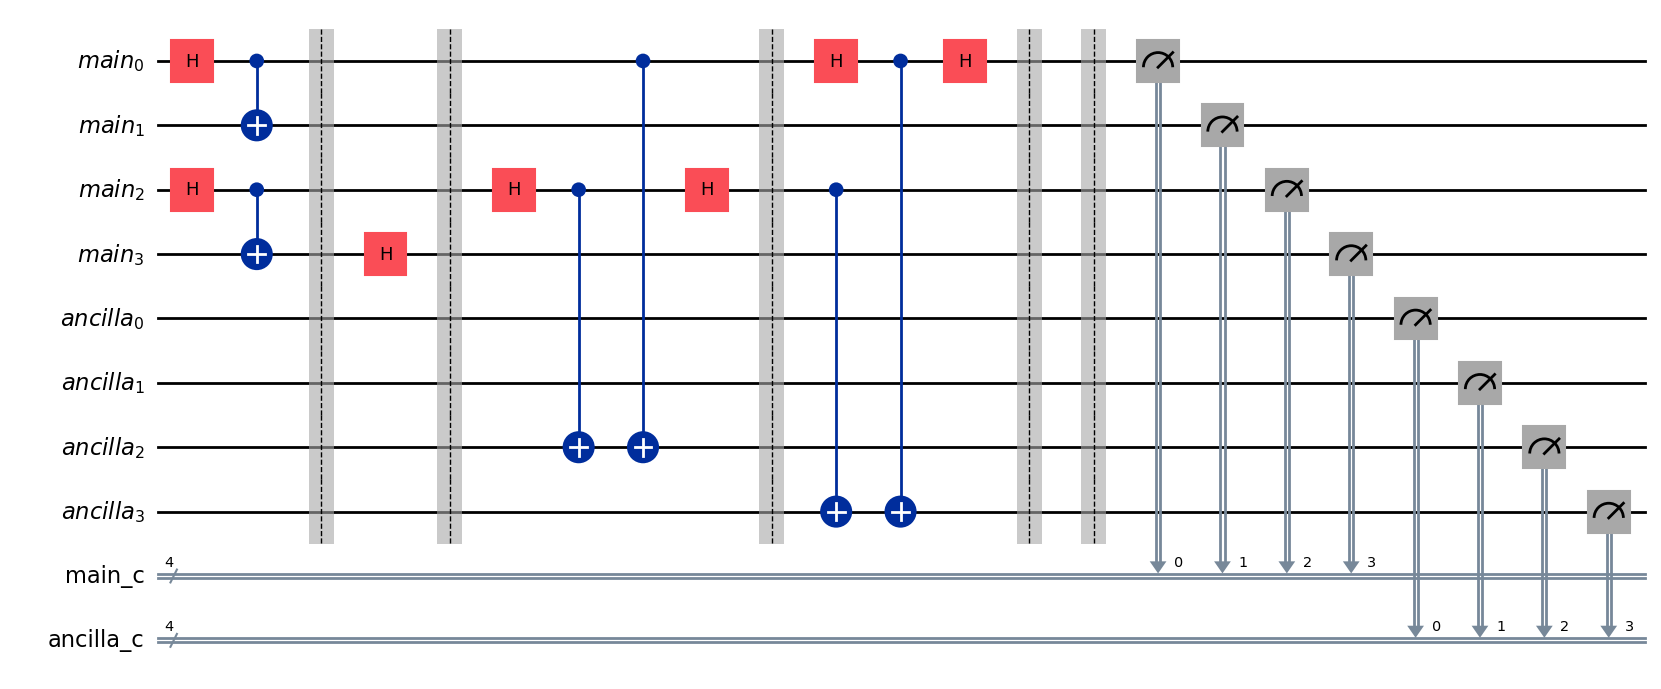

Input pair 3: (1, 0)


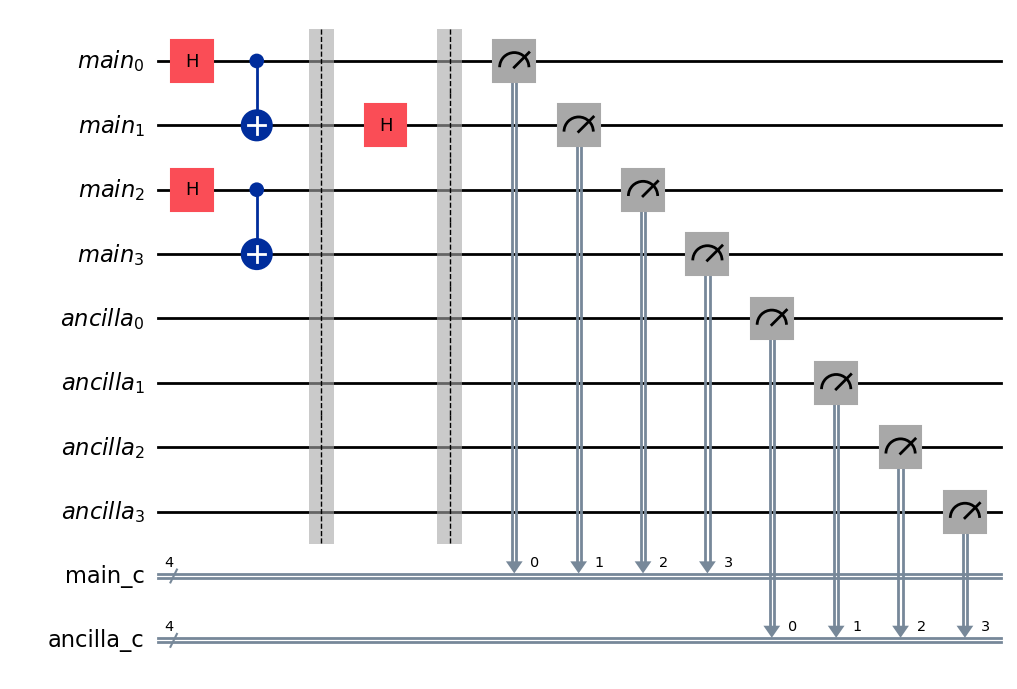

Input pair 4: (1, 1)


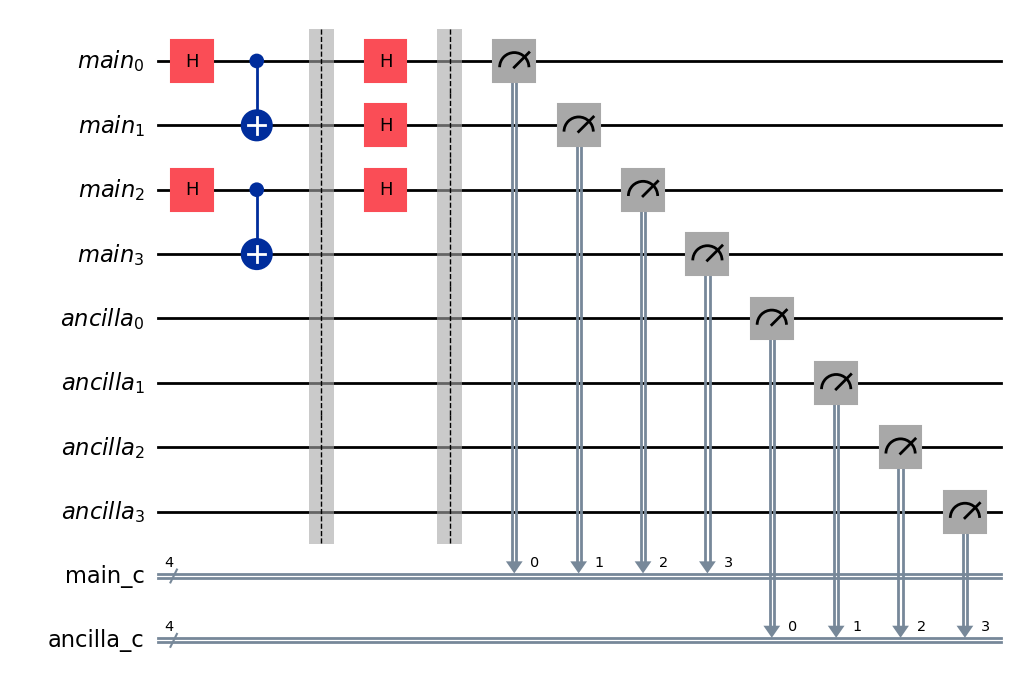

Input pair 5: (1, 2)


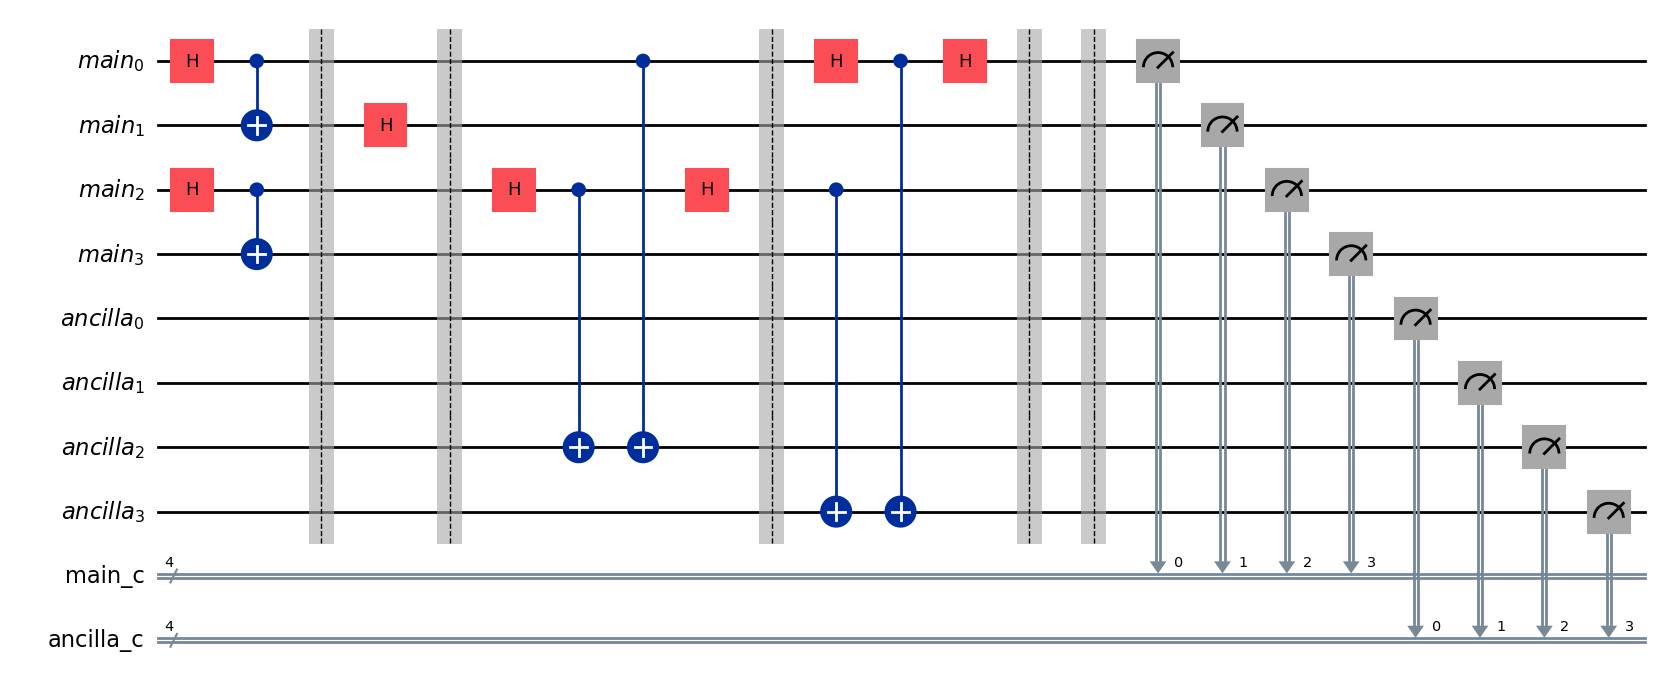

Input pair 6: (2, 0)


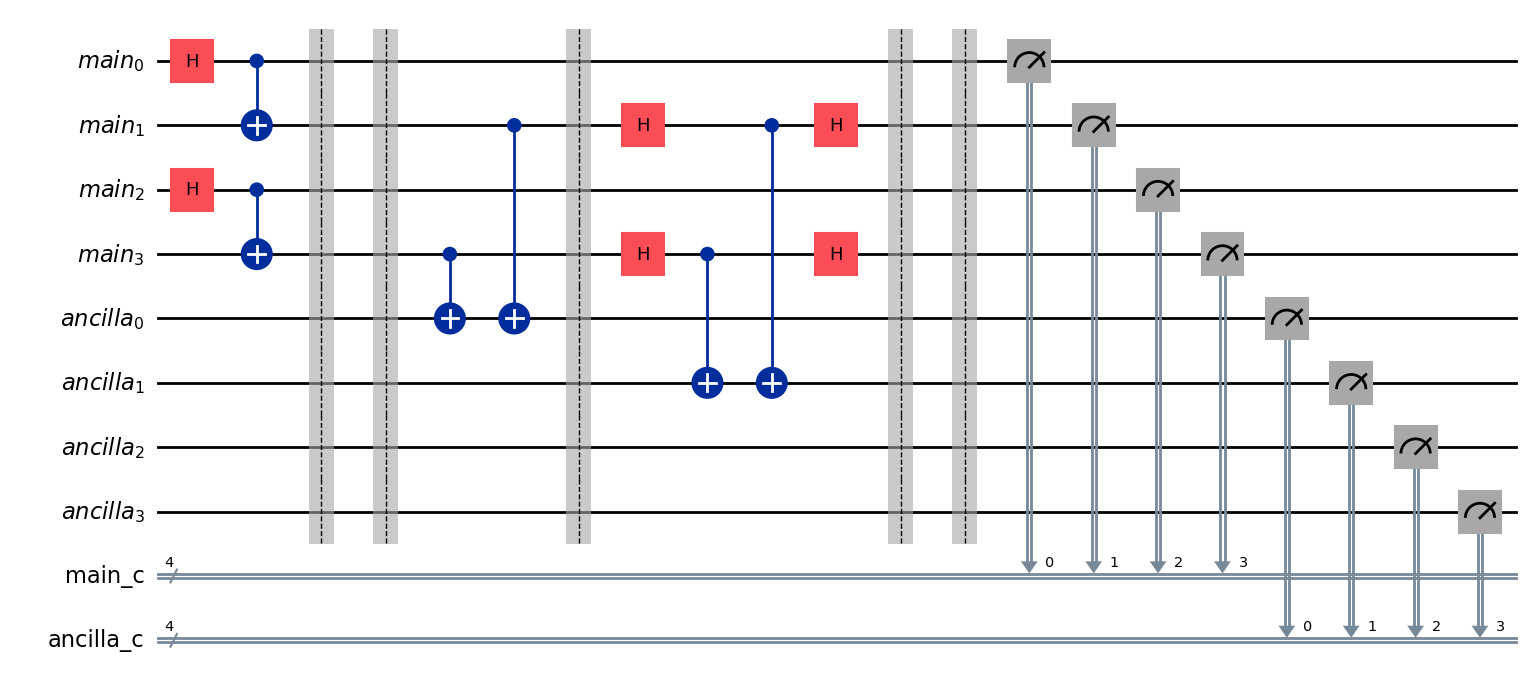

Input pair 7: (2, 1)


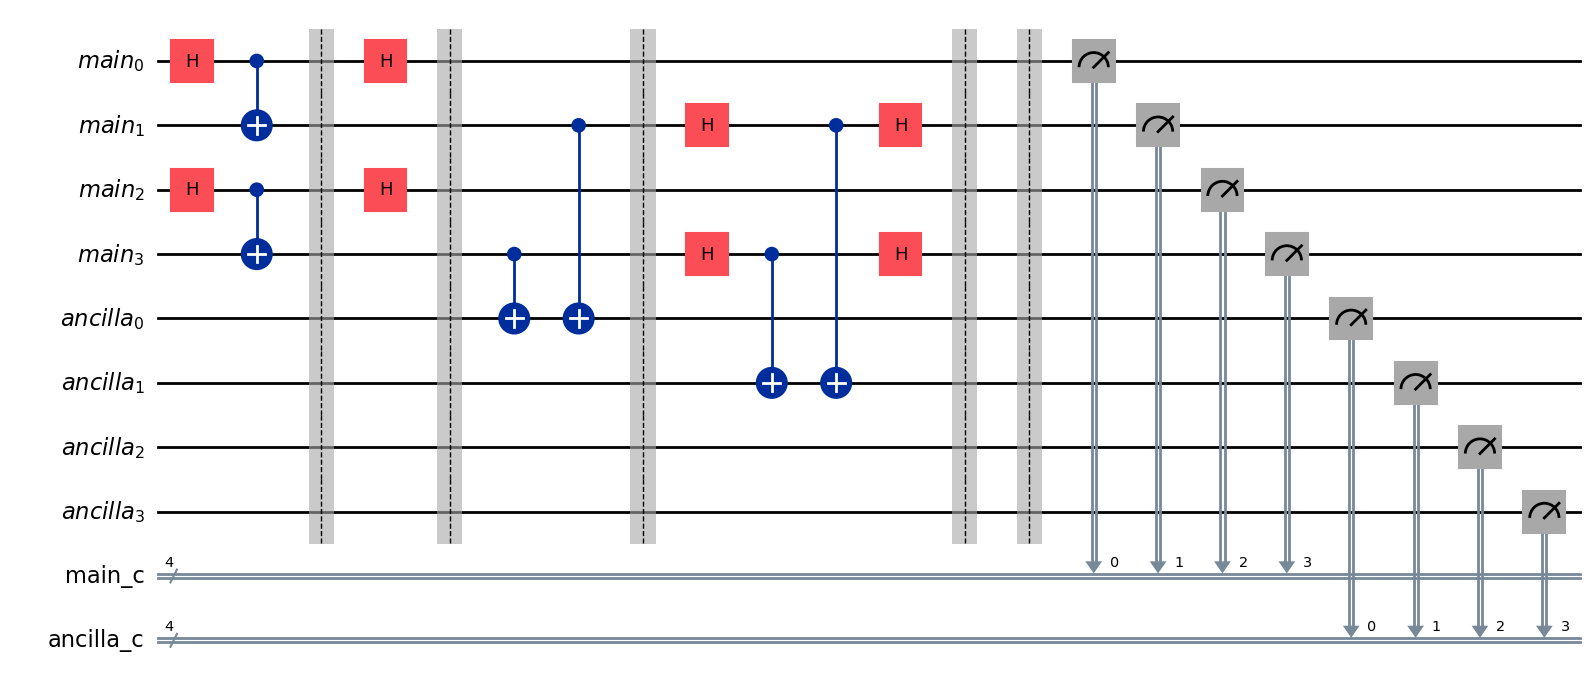

Input pair 8: (2, 2)


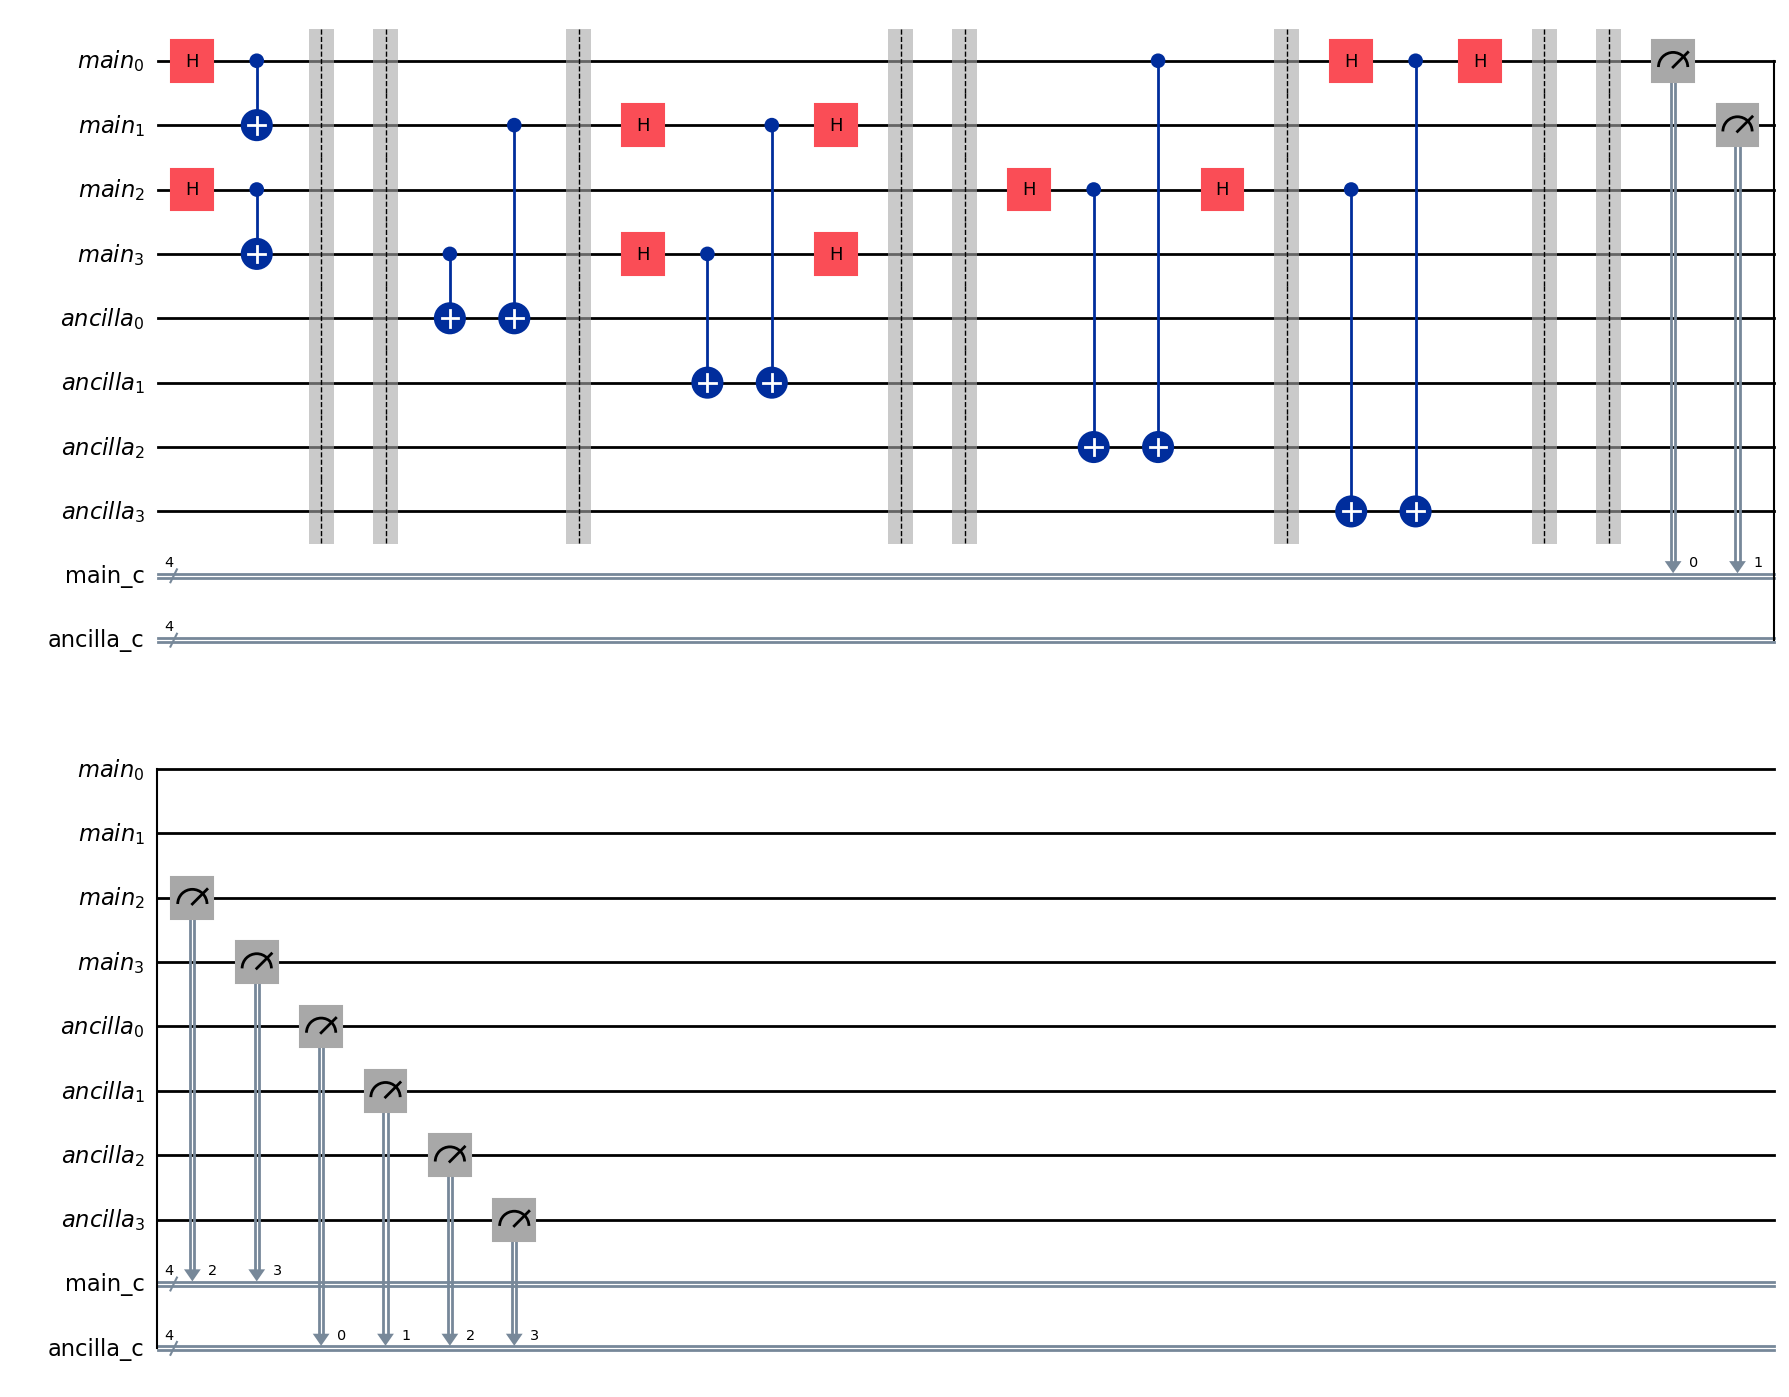

In [24]:
circuits = []
input_pairs = []
for assigned_a in range(3):
    for assigned_b in range(3):
        input_pairs.append((assigned_a, assigned_b))
        circuits.append(create_magic_circuit(assigned_a, assigned_b))

for i, (x_in, y_in) in enumerate(input_pairs):
    print(f"Input pair {i}: ({x_in}, {y_in})")
    display(circuits[i].draw('mpl'))

In [25]:
def calculate_third_bit(bit1, bit2, parity):
    """
    Calculate the third bit based on the first two bits.
    """
    bit1 = int(bit1)
    bit2 = int(bit2)
    if parity == 'even':
        return (bit1 + bit2) % 2
    elif parity == 'odd':
        return (bit1 + bit2 + 1) % 2
    else:
        raise ValueError("Parity must be 'even' or 'odd'.")

In [26]:
def invert_bit(bit):
    """
    Invert the bit.
    """
    return (bit + 1) % 2

In [ ]:
total_trials = 10

results_dict = {}
for circuit in circuits:
    for _ in range(total_trials):
        backend = AerSimulator()
        pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

        isa_qc = pm.run([circuit])
        sampler = Sampler(mode=backend)
        job = sampler.run(isa_qc, shots=1)
        result = job.result()

        bitarray_main = result[0].data.main_c
        bitarray_ancilla = result[0].data.ancilla_c

        # bitstring_main = ''.join('1' if bit else '0' for bit in bitarray_main.to_bool_array()[0])
        bitstring_main = bitarray_main.get_bitstrings()[0]
        # bitstring_ancilla = ''.join('1' if bit else '0' for bit in bitarray_ancilla.to_bool_array()[0])
        bitstring_ancilla = bitarray_ancilla.get_bitstrings()[0]

        row = circuit.name.split('_')[-1][1]
        col = circuit.name.split('_')[-1][-2]

        if row == '0':
            alice_bit = [int(bitstring_main[3-1]), int(bitstring_main[3-3]), calculate_third_bit(bitstring_main[3-1], bitstring_main[3-3], 'even')]
        elif row == '1':
            alice_bit = [int(bitstring_main[3-3]), int(bitstring_main[3-1]), calculate_third_bit(bitstring_main[3-1], bitstring_main[3-3], 'even')]
        elif row == '2':
            alice_bit = [invert_bit(int(bitstring_ancilla[3-0])), invert_bit(int(bitstring_ancilla[3-1])), calculate_third_bit(invert_bit(int(bitstring_ancilla[3-0])), invert_bit(int(bitstring_ancilla[3-1])), 'even')]
        
        if col == '0':
            bob_bit = [int(bitstring_main[3-0]), int(bitstring_main[3-2]), calculate_third_bit(bitstring_main[3-0], bitstring_main[3-2], 'odd')]
        elif col == '1':
            bob_bit = [int(bitstring_main[3-2]), int(bitstring_main[3-0]), calculate_third_bit(bitstring_main[3-0], bitstring_main[3-2], 'odd')]
        elif col == '2':
            bob_bit = [int(bitstring_ancilla[3-2]), int(bitstring_ancilla[3-3]), calculate_third_bit(int(bitstring_ancilla[3-2]), int(bitstring_ancilla[3-3]), 'odd')]
        
        results_dict[(row, col)] = results_dict.get((row, col), [])
        results_dict[(row, col)].append((alice_bit, bob_bit))

In [29]:
print("Results Dictionary:")
for key, value in results_dict.items():
    print(f"{key}: {value}")
print("Results Dictionary Length:", len(results_dict))

Results Dictionary:
('0', '0'): [([1, 0, 1], [1, 1, 1]), ([0, 1, 1], [0, 0, 1]), ([1, 1, 0], [1, 1, 1]), ([0, 0, 0], [0, 0, 1]), ([0, 1, 1], [0, 1, 0]), ([1, 1, 0], [1, 1, 1]), ([1, 0, 1], [1, 1, 1]), ([1, 0, 1], [1, 0, 0]), ([0, 0, 0], [0, 0, 1]), ([0, 0, 0], [0, 0, 1])]
('0', '1'): [([1, 0, 1], [0, 0, 1]), ([0, 0, 0], [0, 1, 0]), ([0, 1, 1], [1, 1, 1]), ([0, 0, 0], [0, 0, 1]), ([0, 1, 1], [1, 1, 1]), ([0, 1, 1], [1, 1, 1]), ([1, 0, 1], [0, 1, 0]), ([1, 1, 0], [1, 1, 1]), ([1, 0, 1], [0, 0, 1]), ([1, 1, 0], [1, 1, 1])]
('0', '2'): [([1, 0, 1], [1, 0, 0]), ([0, 1, 1], [1, 1, 1]), ([0, 1, 1], [1, 1, 1]), ([1, 1, 0], [0, 0, 1]), ([1, 1, 0], [0, 0, 1]), ([1, 0, 1], [1, 0, 0]), ([0, 0, 0], [0, 0, 1]), ([0, 1, 1], [1, 1, 1]), ([0, 0, 0], [0, 1, 0]), ([1, 0, 1], [1, 0, 0])]
('1', '0'): [([0, 0, 0], [0, 0, 1]), ([0, 0, 0], [1, 0, 0]), ([1, 0, 1], [1, 1, 1]), ([0, 1, 1], [1, 0, 0]), ([1, 0, 1], [0, 1, 0]), ([1, 1, 0], [0, 1, 0]), ([0, 1, 1], [0, 0, 1]), ([0, 1, 1], [1, 0, 0]), ([1, 1, 0], [0, 

In [30]:
def magic_square_score(alice_row, bob_col, assigned_a, assigned_b):
    """
    Calculate the score for the magic square based on Alice's row and Bob's column.
    """
    if assigned_a not in range(3) or assigned_b not in range(3):
        raise ValueError("assigned_a and assigned_b must be between 0 and 2.")
    
    alice_row = np.array(alice_row)
    bob_col = np.array(bob_col)

    win = True

    if np.sum(alice_row) % 2 != 0:
        print("Alice's row is not even")
        win = False
    if np.sum(bob_col) % 2 != 1:
        print("Bob's column is not odd")
        win = False
    if alice_row[assigned_b] != bob_col[assigned_a]:
        print("Alice's row and Bob's column intersect at a different value")
        win = False
    
    return win

In [36]:
for (row, col), results in results_dict.items():
    print(f"Results for ({row}, {col}):")
    for alice_bit, bob_bit in results:
        score = magic_square_score(alice_bit, bob_bit, int(row), int(col))
        print(f"Alice's bits: {alice_bit}, Bob's bits: {bob_bit}, Score: {score}")
    print("\n")

Results for (0, 0):
Alice's bits: [1, 0, 1], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [0, 1, 1], Bob's bits: [0, 0, 1], Score: True
Alice's bits: [1, 1, 0], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [0, 0, 0], Bob's bits: [0, 0, 1], Score: True
Alice's bits: [0, 1, 1], Bob's bits: [0, 1, 0], Score: True
Alice's bits: [1, 1, 0], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [1, 0, 1], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [1, 0, 1], Bob's bits: [1, 0, 0], Score: True
Alice's bits: [0, 0, 0], Bob's bits: [0, 0, 1], Score: True
Alice's bits: [0, 0, 0], Bob's bits: [0, 0, 1], Score: True


Results for (0, 1):
Alice's bits: [1, 0, 1], Bob's bits: [0, 0, 1], Score: True
Alice's bits: [0, 0, 0], Bob's bits: [0, 1, 0], Score: True
Alice's bits: [0, 1, 1], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [0, 0, 0], Bob's bits: [0, 0, 1], Score: True
Alice's bits: [0, 1, 1], Bob's bits: [1, 1, 1], Score: True
Alice's bits: [0, 1, 1], Bob's bits: [1, 1, 1], Score: Tru

In [31]:
def magic_square_visualization(alice_row, bob_col, assigned_a, assigned_b):
    """
    Visualize the magic square based on Alice's row and Bob's column.
    """
    if assigned_a not in range(3) or assigned_b not in range(3):
        raise ValueError("assigned_a and assigned_b must be between 0 and 2.")
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))

    for row in range(3):
        for col in range(3):
            if row == assigned_a and col == assigned_b:
                if alice_row[assigned_b] != bob_col[assigned_a]:
                    ax.text(col + 0.4, row + 0.4, str(alice_row[col]), 
                            ha='center', va='center', fontsize=20, color='darkred')
                    ax.text(col + 0.6, row + 0.6, str(bob_col[row]), 
                            ha='center', va='center', fontsize=20, color='darkred')
                else:
                    ax.text(col + 0.5, row + 0.5, str(alice_row[col]), 
                            ha='center', va='center', fontsize=20, color='green')
                continue

            if row == assigned_a:
                if np.sum(alice_row) % 2 != 0:
                    ax.text(col + 0.5, row + 0.5, str(alice_row[col]), 
                            ha='center', va='center', fontsize=20, color='red')
                else:
                    ax.text(col + 0.5, row + 0.5, str(alice_row[col]), 
                            ha='center', va='center', fontsize=20, color='blue')
            if col == assigned_b:
                if np.sum(bob_col) % 2 != 1:
                    ax.text(col + 0.5, row + 0.5, str(bob_col[row]), 
                            ha='center', va='center', fontsize=20, color='red')
                else:
                    ax.text(col + 0.5, row + 0.5, str(bob_col[row]), 
                            ha='center', va='center', fontsize=20, color='blue')
    
    ax.invert_yaxis()

    plt.xticks(color='w')
    plt.yticks(color='w')
    plt.grid(True)
    plt.show()

Alice's row is not even
Bob's column is not odd
False


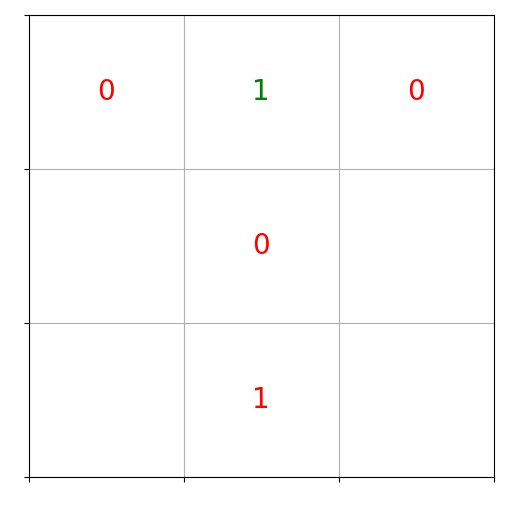

In [ ]:
print(magic_square_score([0, 1, 0], [1, 0, 1], 0, 1))  # Alice's not even, Bob's not odd, should return False
magic_square_visualization([0, 1, 0], [1, 0, 1], 0, 1)

True


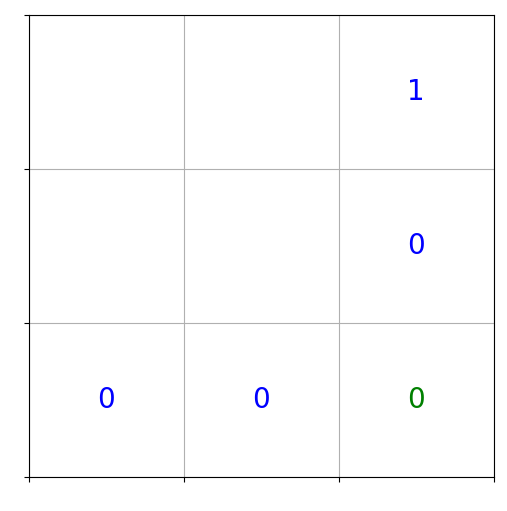

In [ ]:
print(magic_square_score([0, 0, 0], [1, 0, 0], 2, 2))  # Should return True
magic_square_visualization([0, 0, 0], [1, 0, 0], 2, 2)

Alice's row and Bob's column intersect at a different value


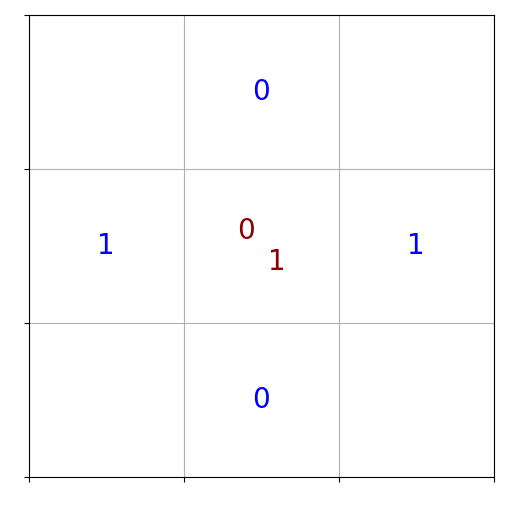

In [ ]:
magic_square_score([1, 0, 1], [0, 1, 0], 1, 1)  # Intersect is not the same, should return False
magic_square_visualization([1, 0, 1], [0, 1, 0], 1, 1)

Results for (0, 0):


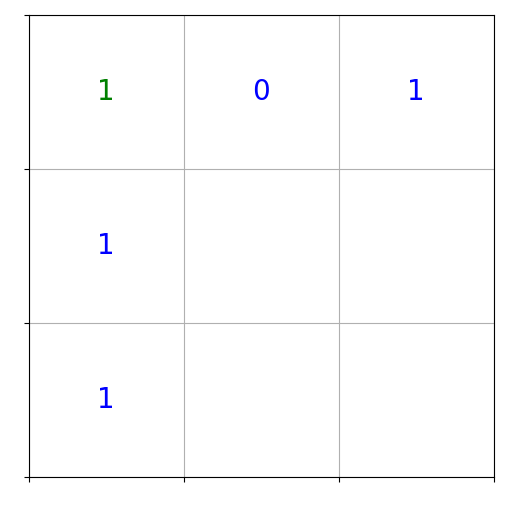

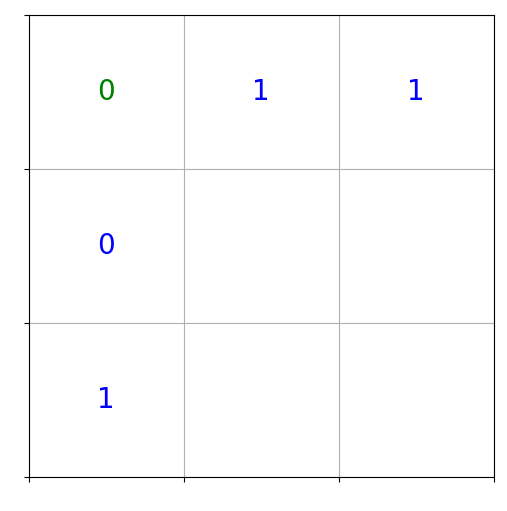

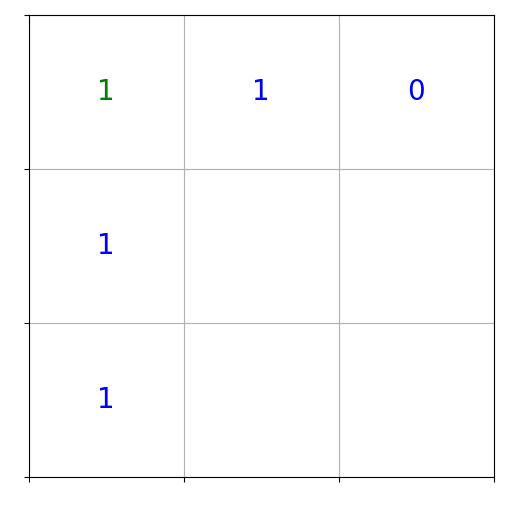

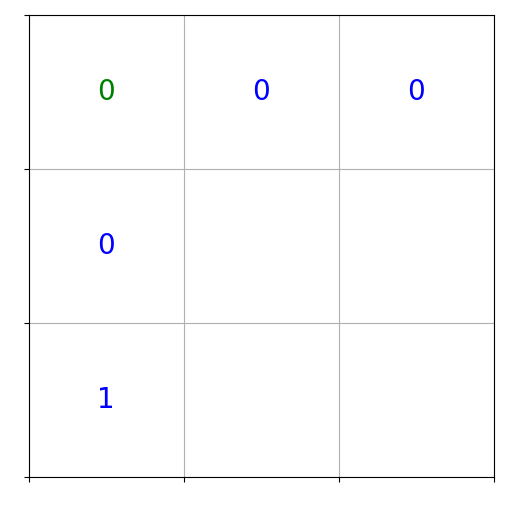

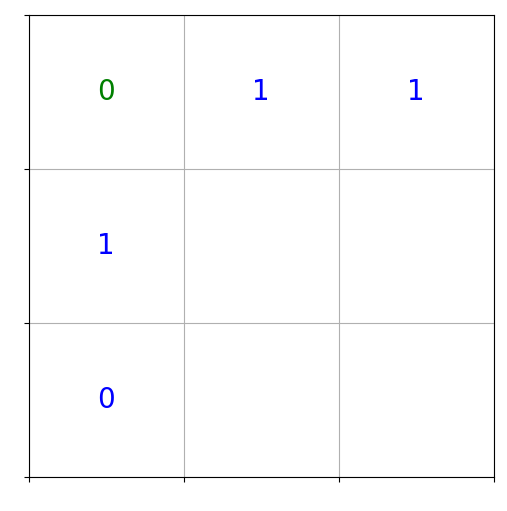

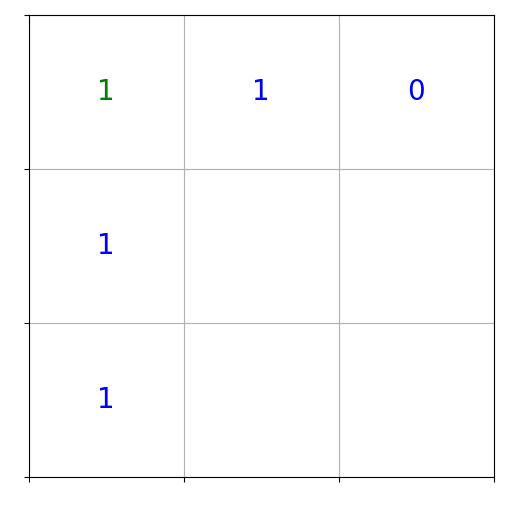

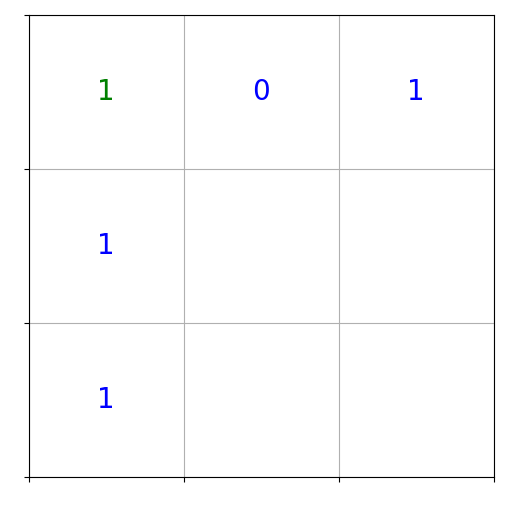

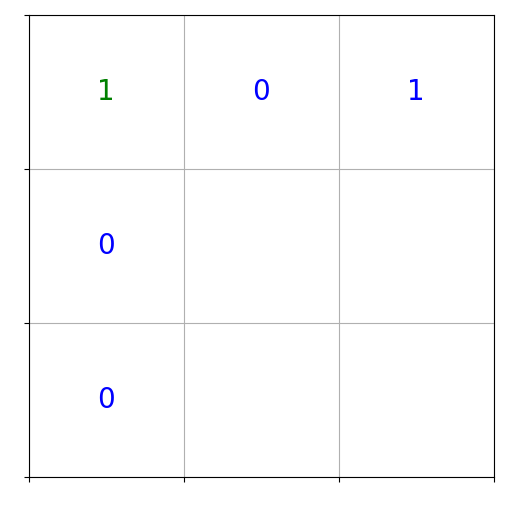

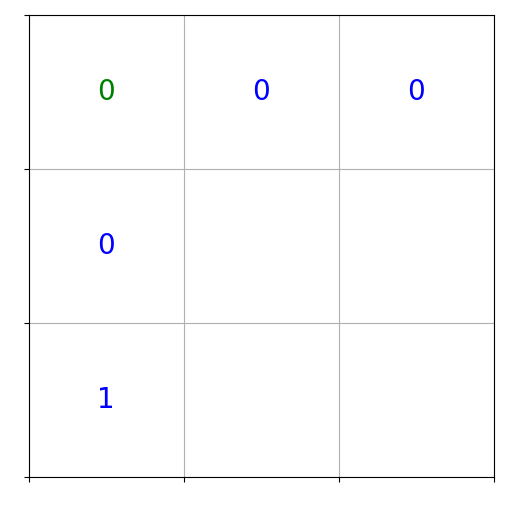

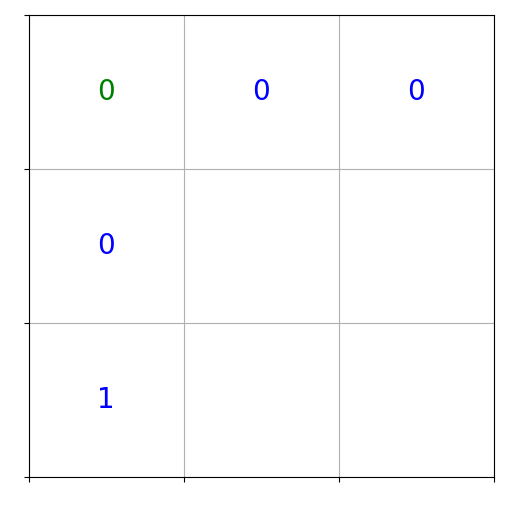

Results for (0, 1):


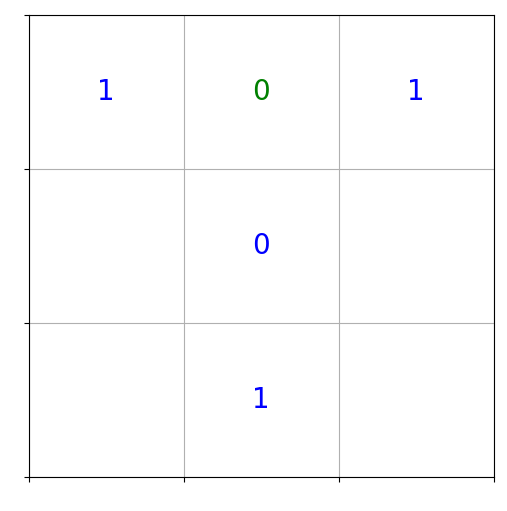

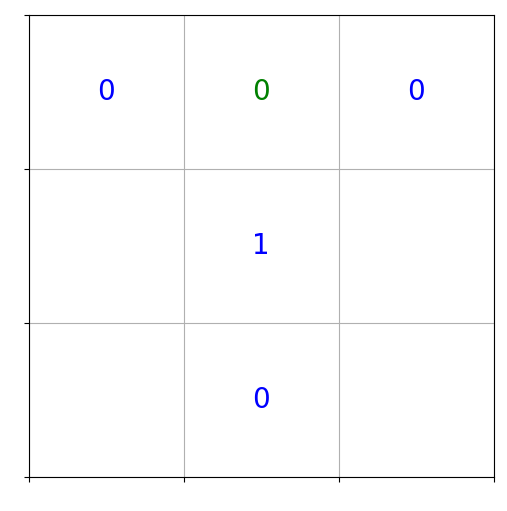

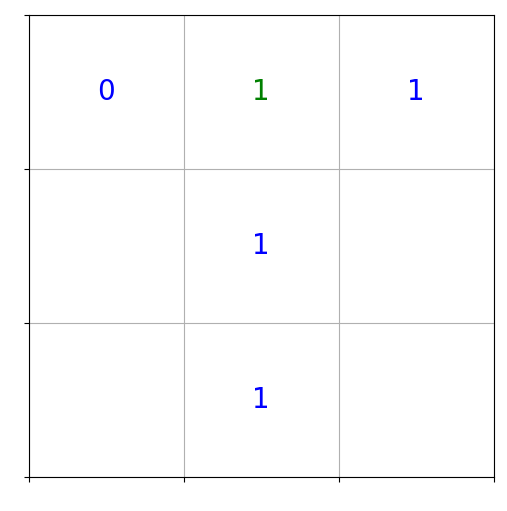

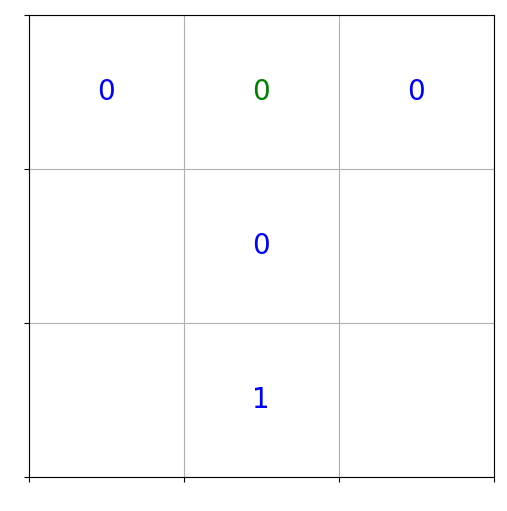

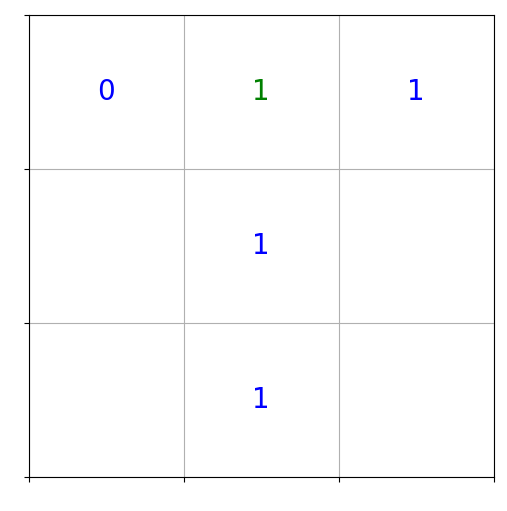

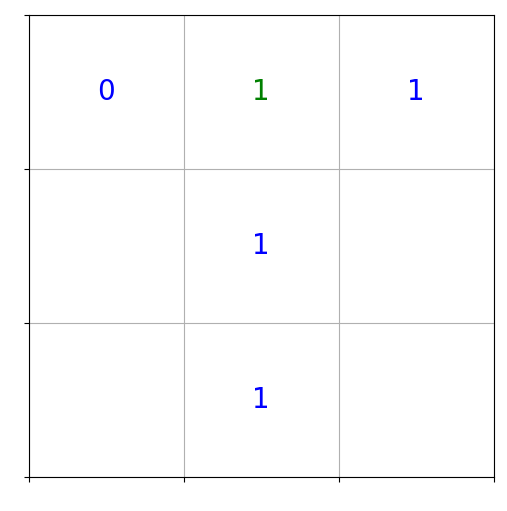

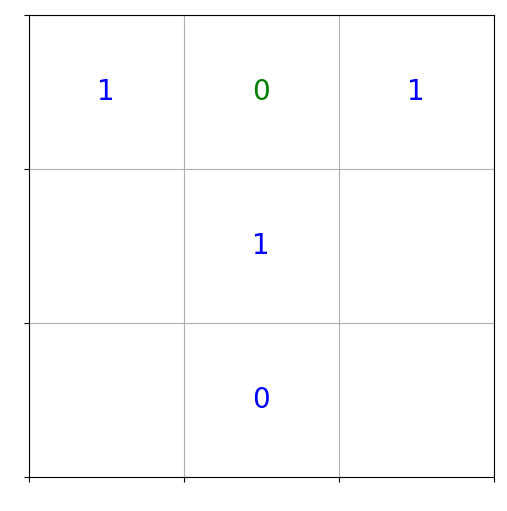

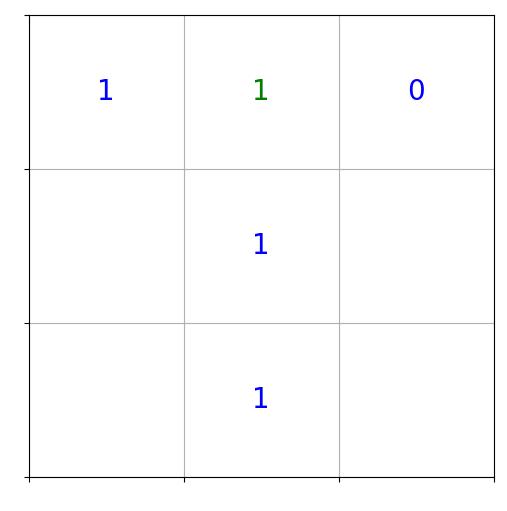

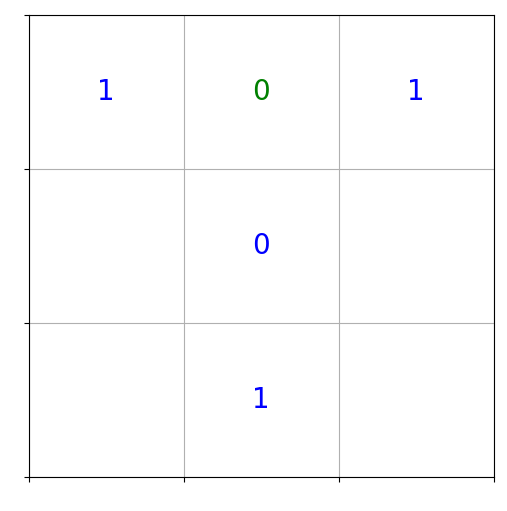

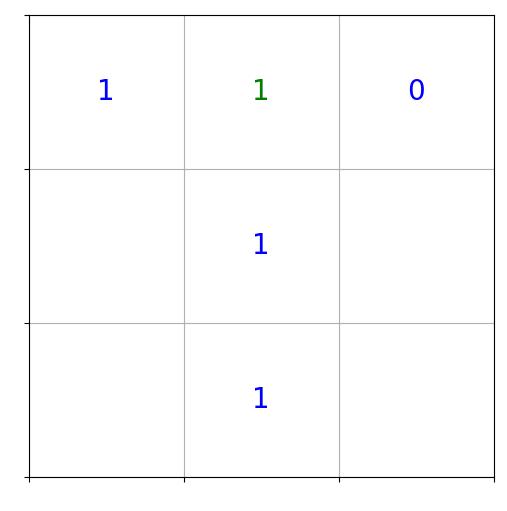

Results for (0, 2):


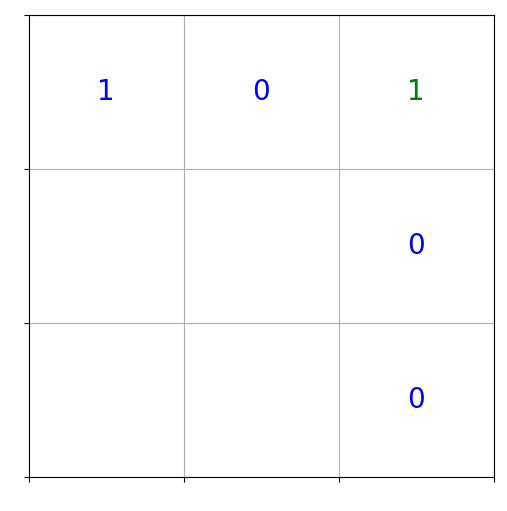

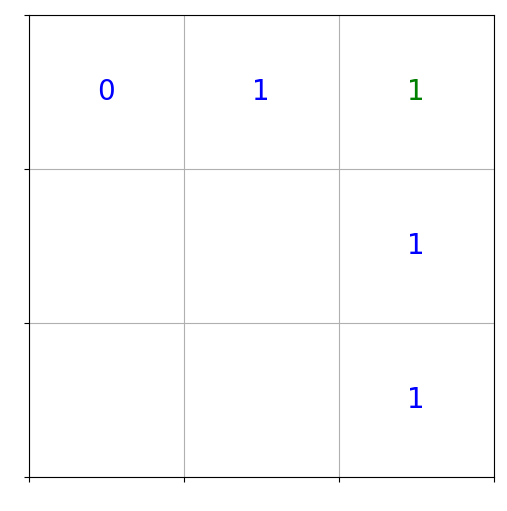

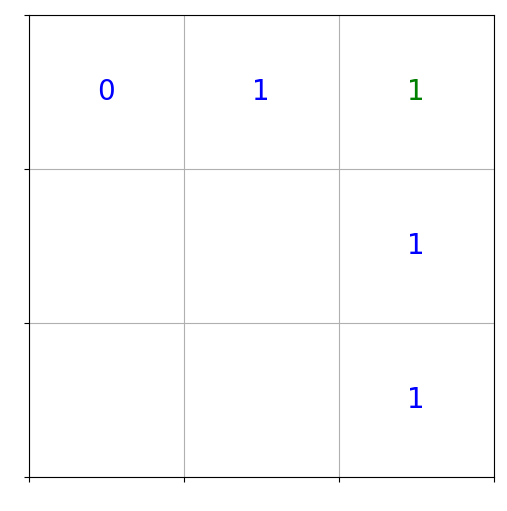

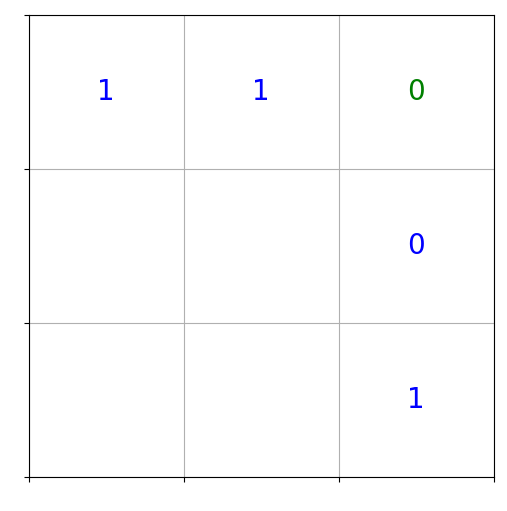

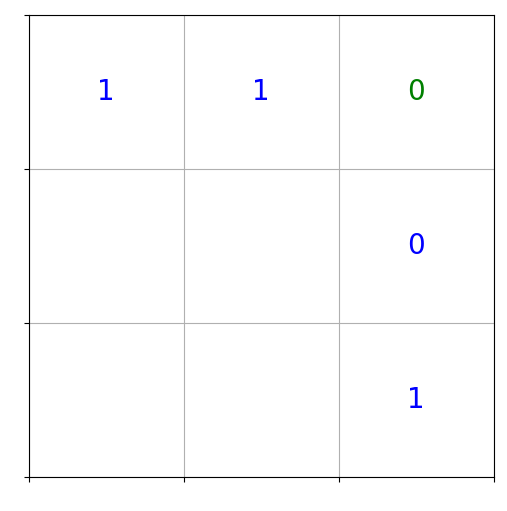

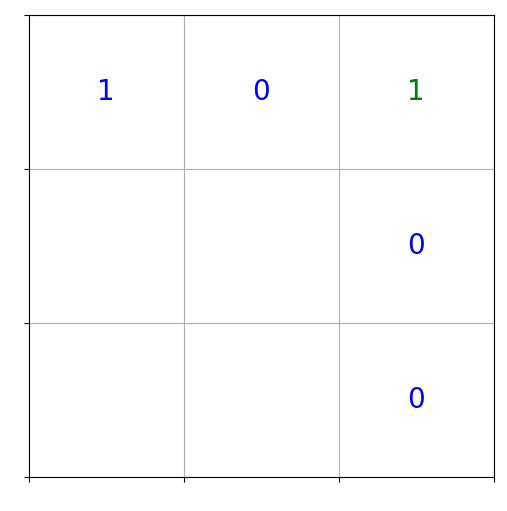

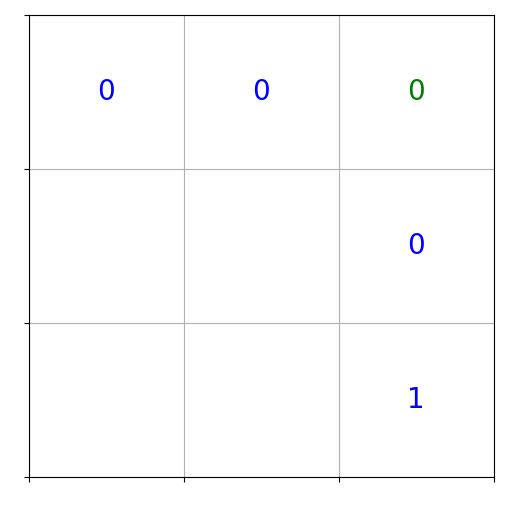

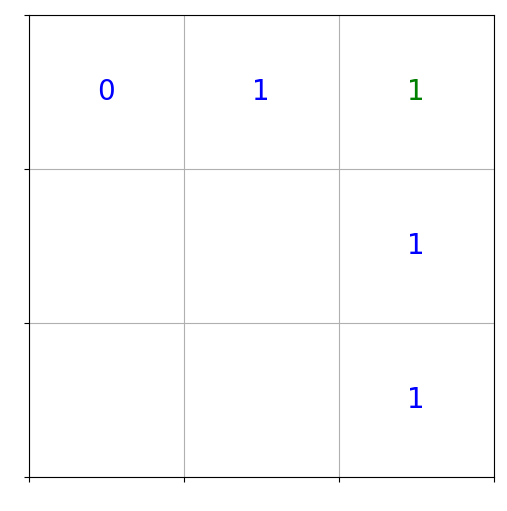

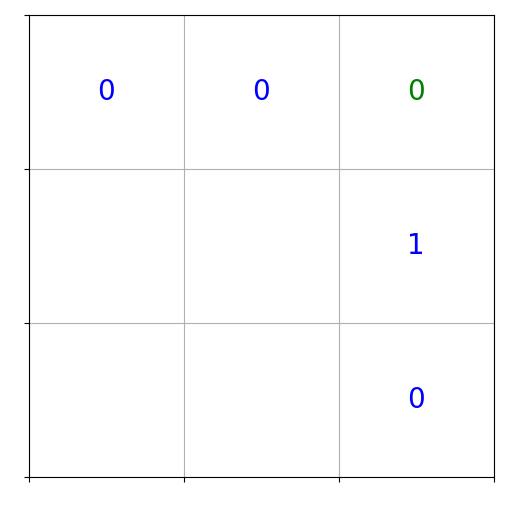

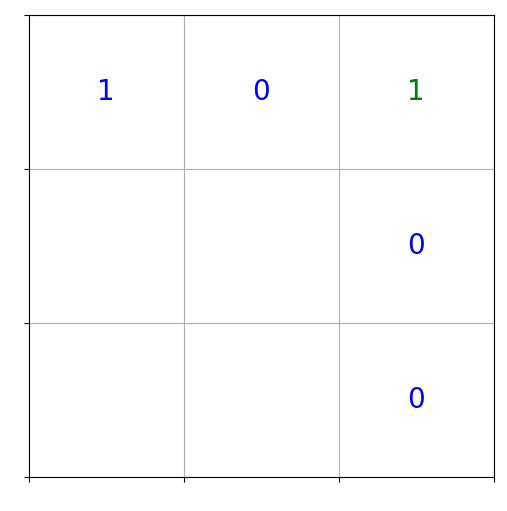

Results for (1, 0):


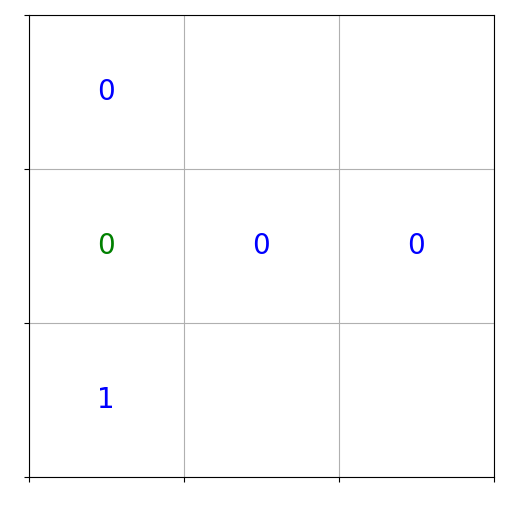

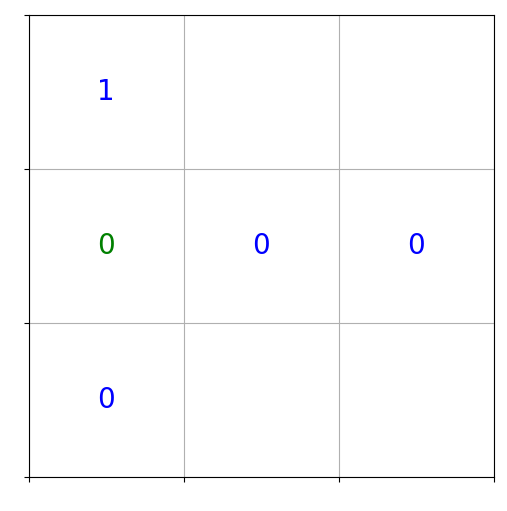

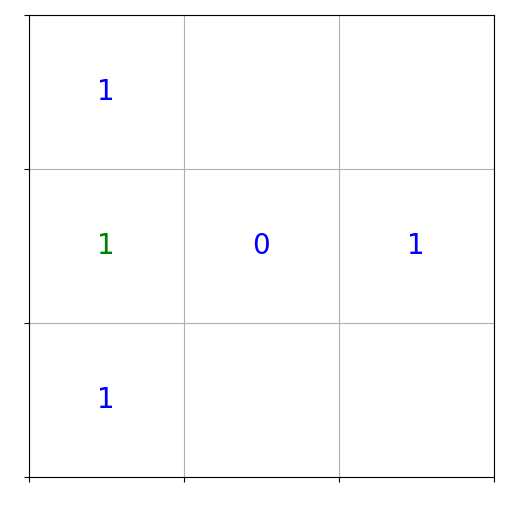

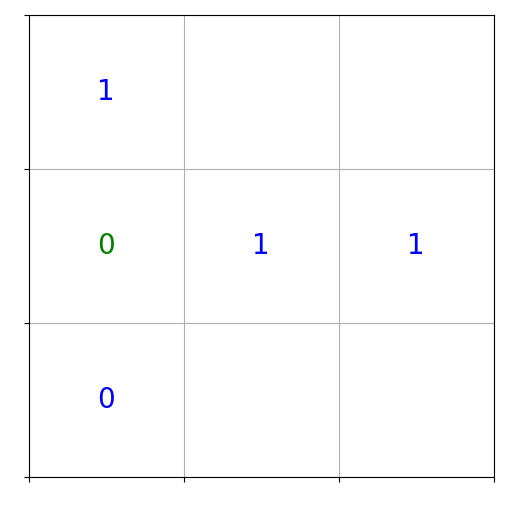

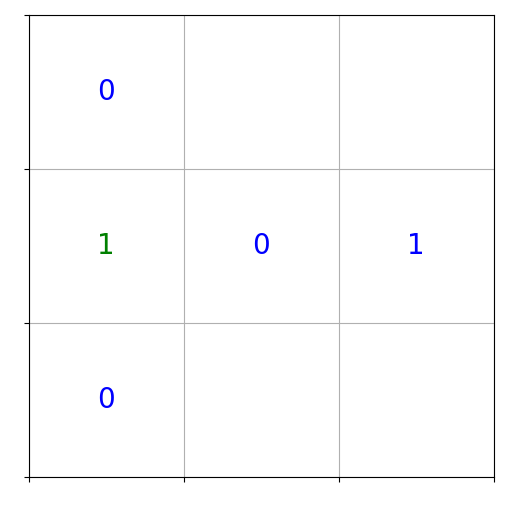

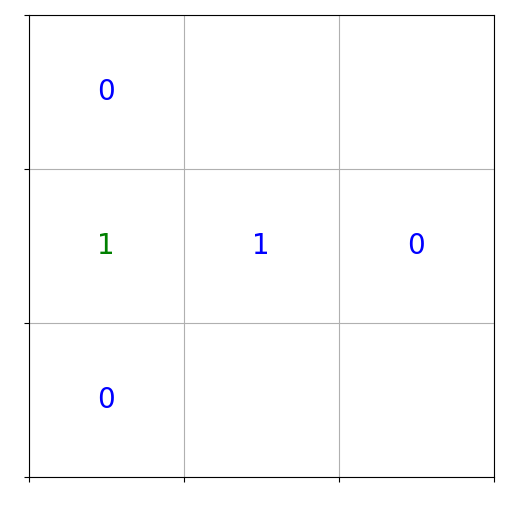

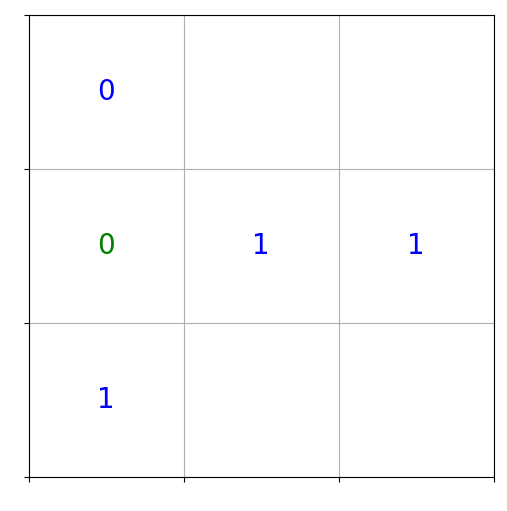

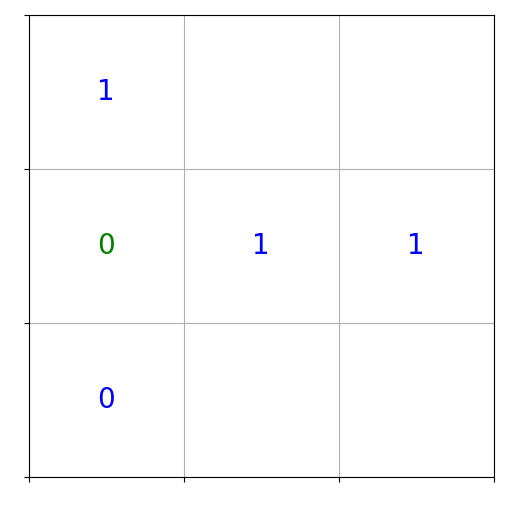

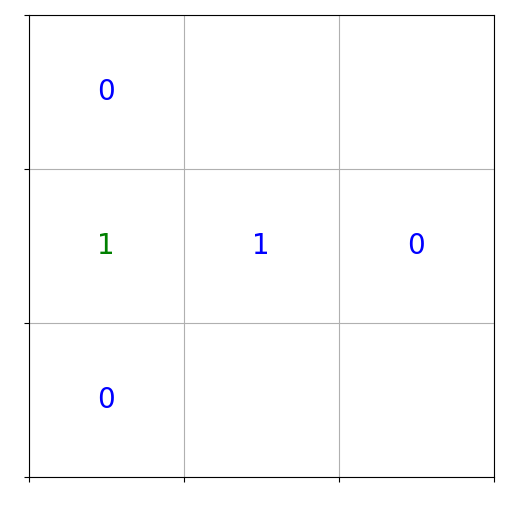

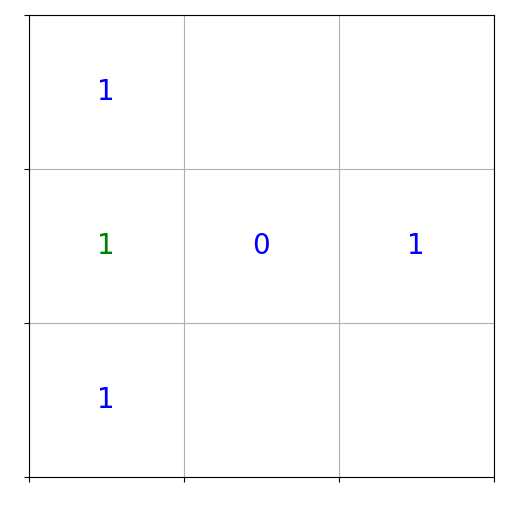

Results for (1, 1):


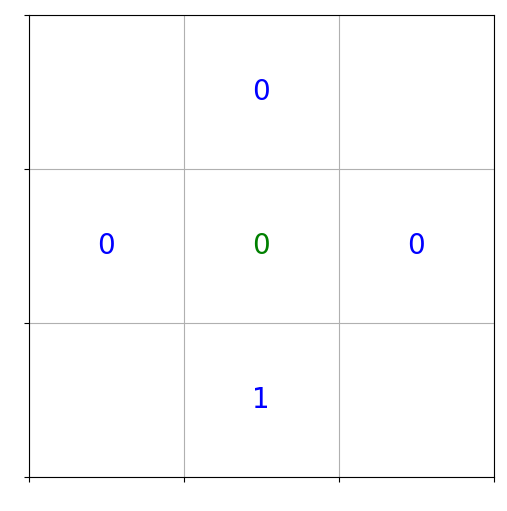

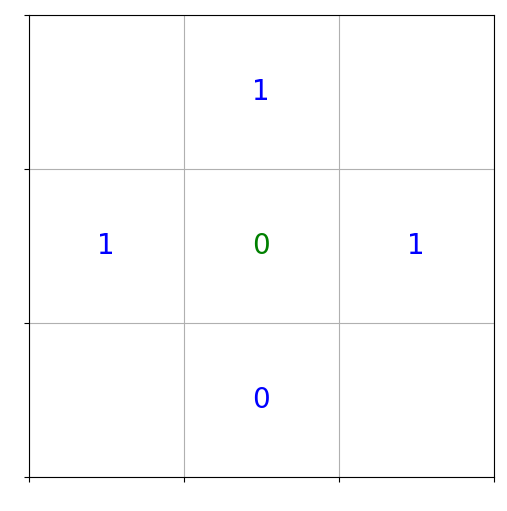

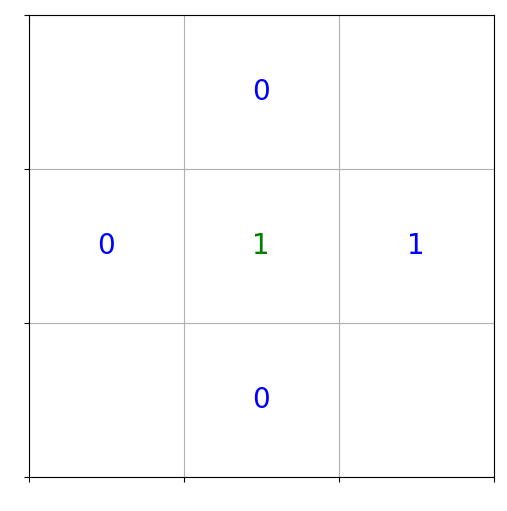

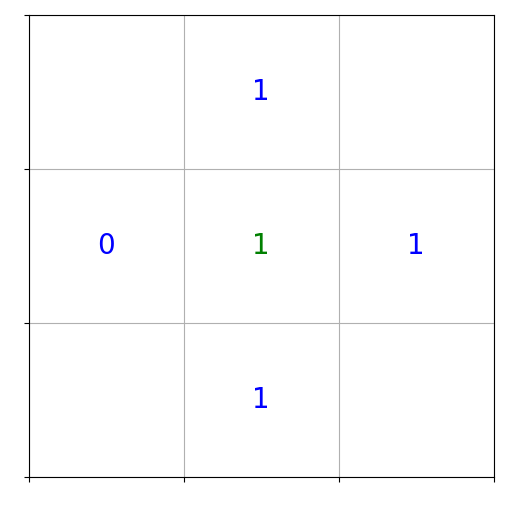

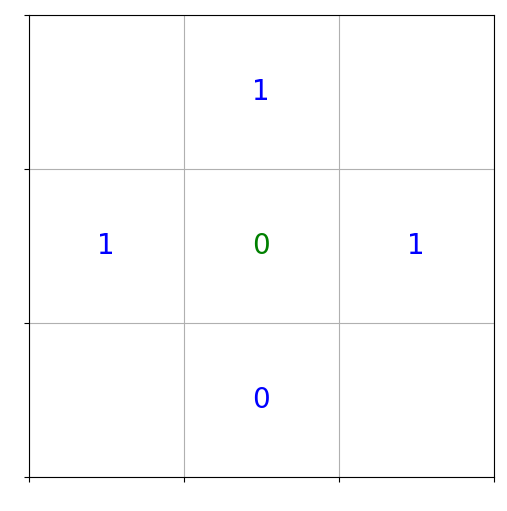

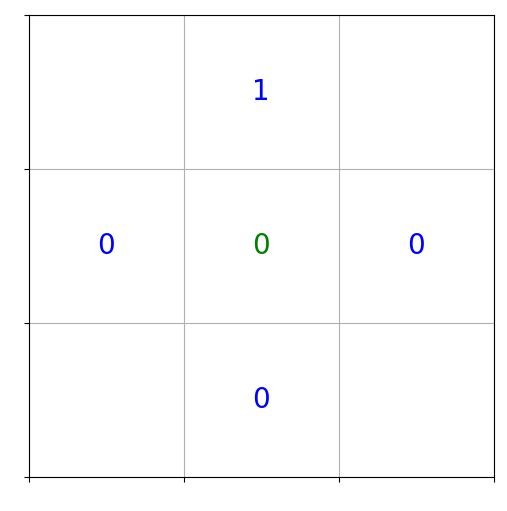

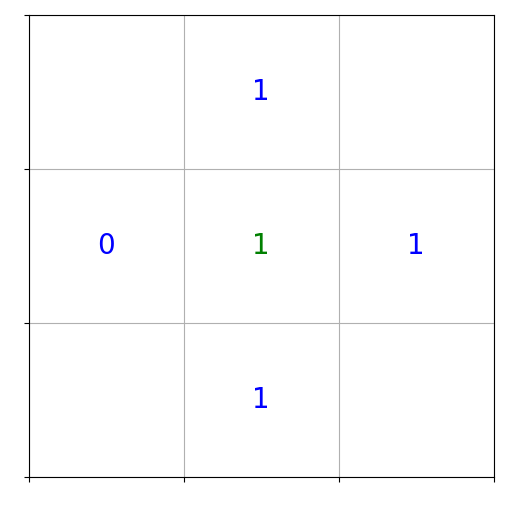

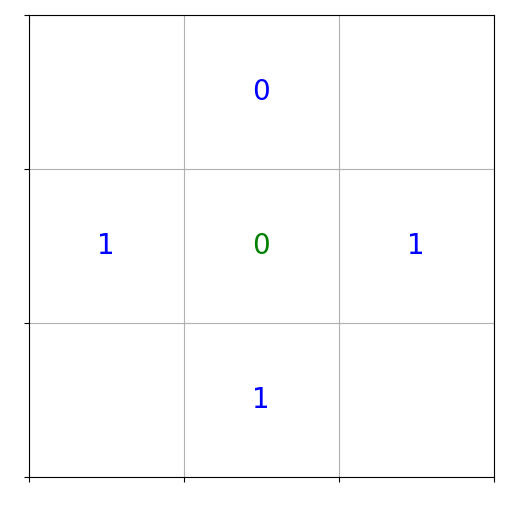

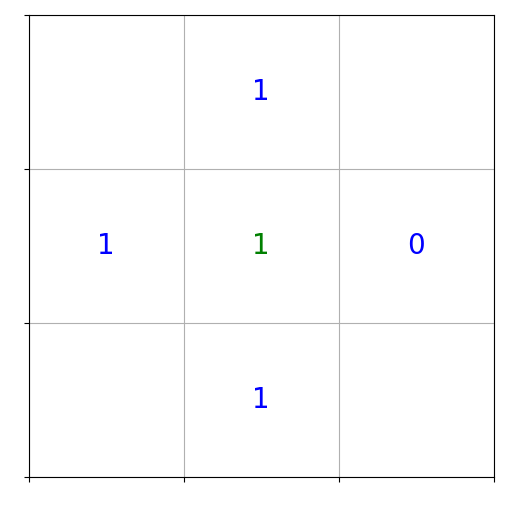

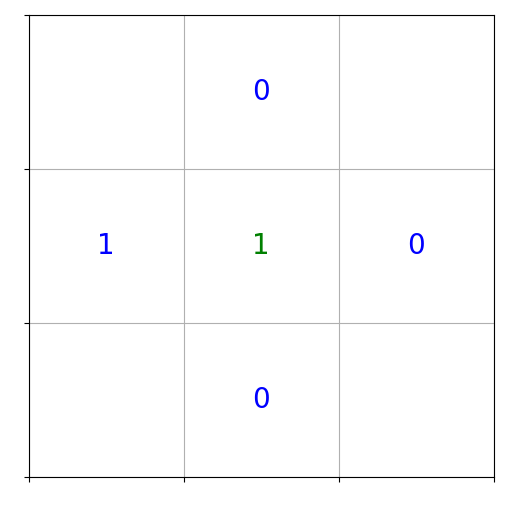

Results for (1, 2):


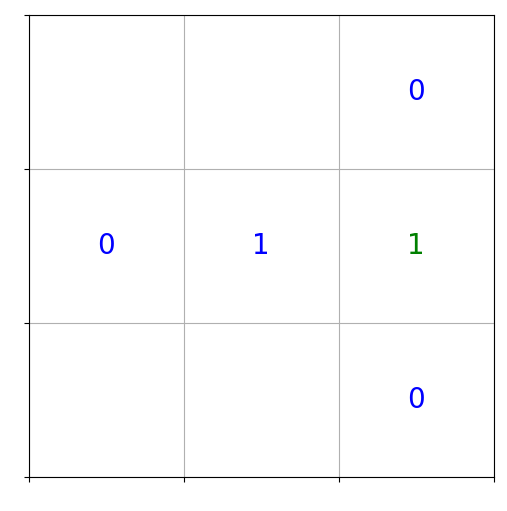

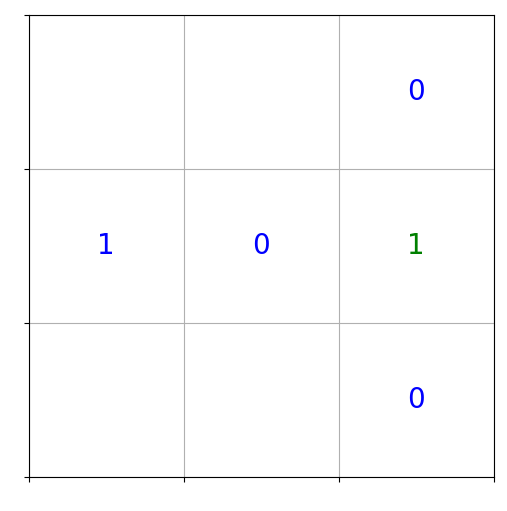

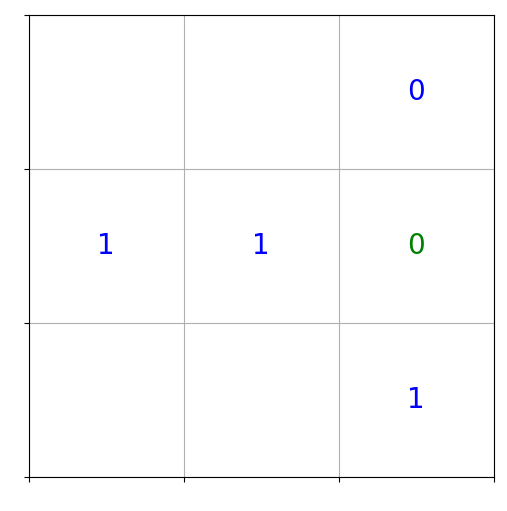

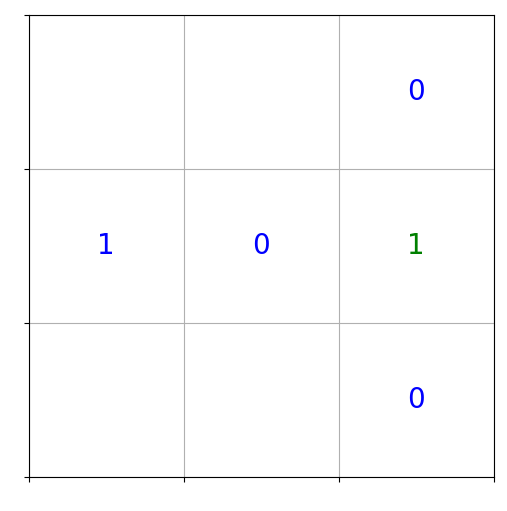

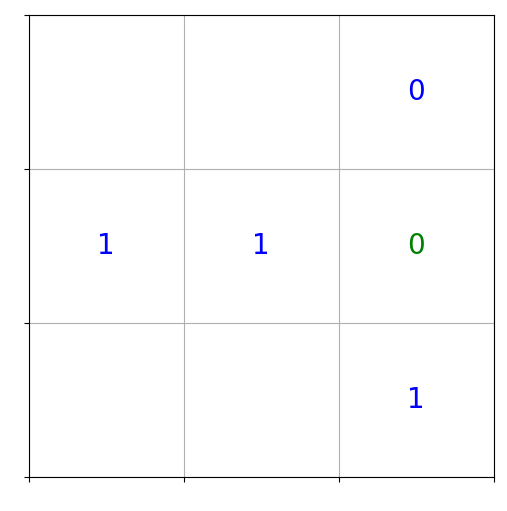

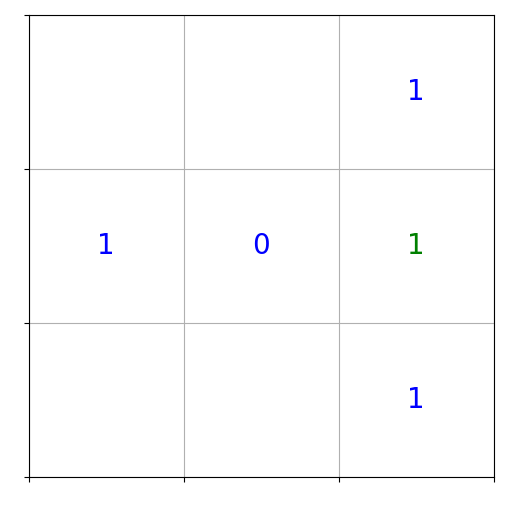

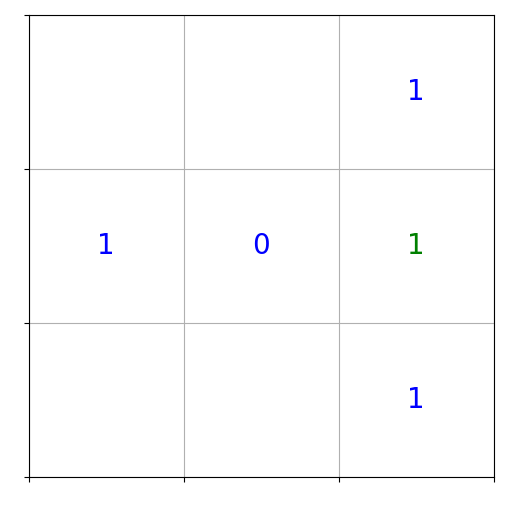

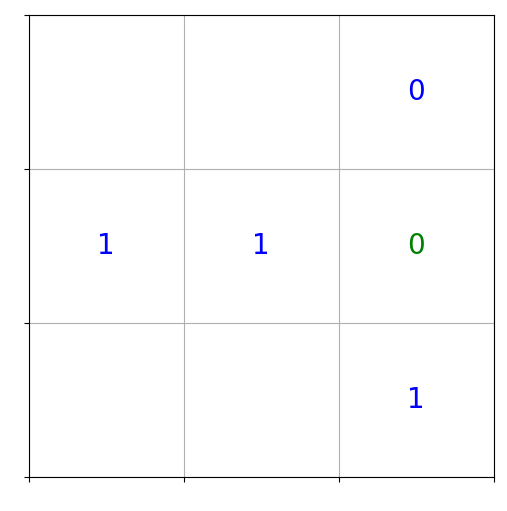

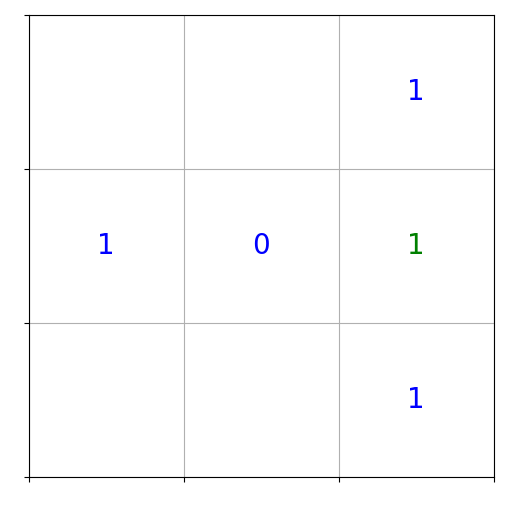

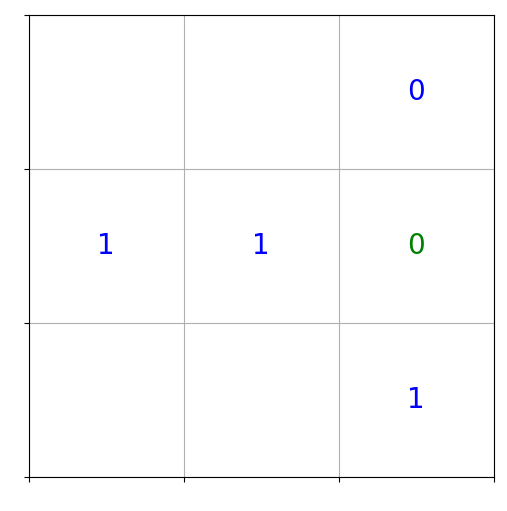

Results for (2, 0):


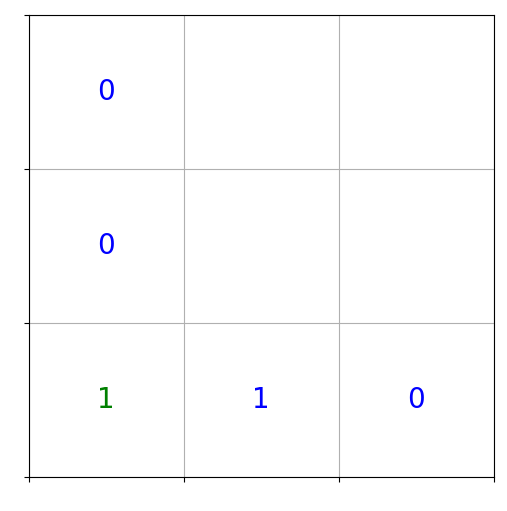

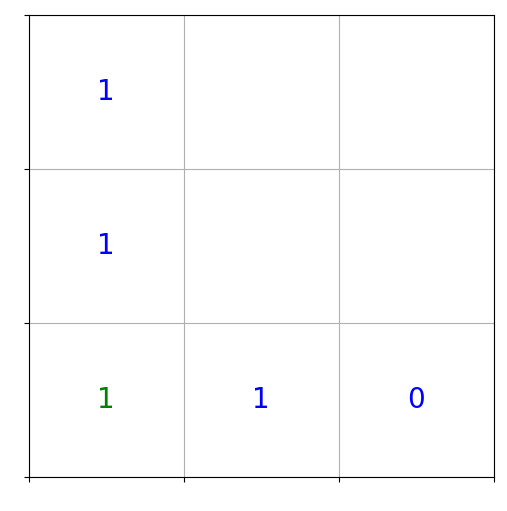

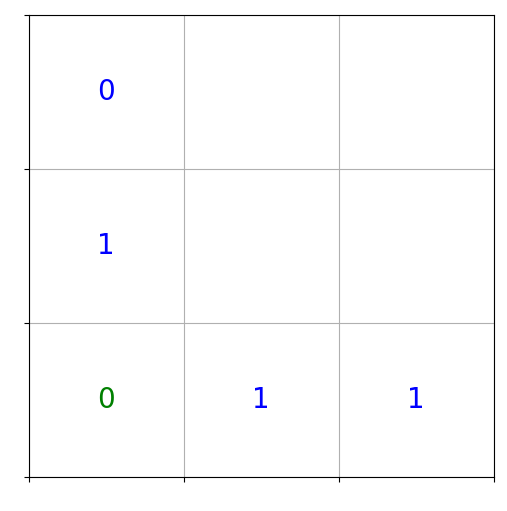

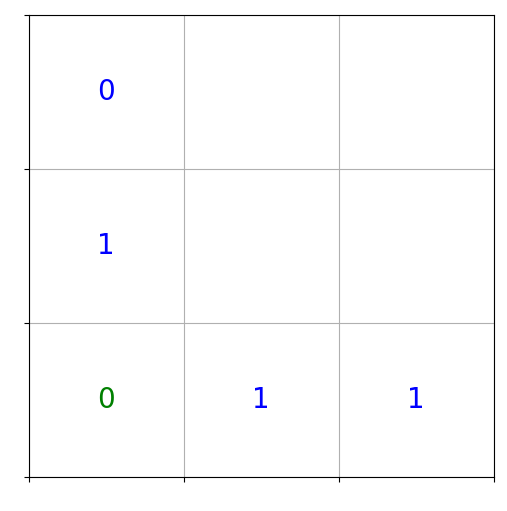

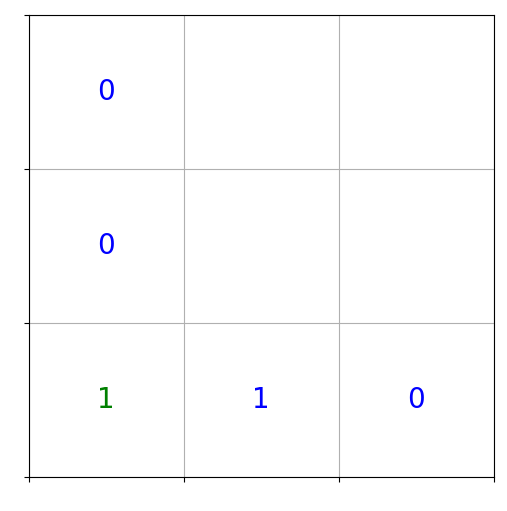

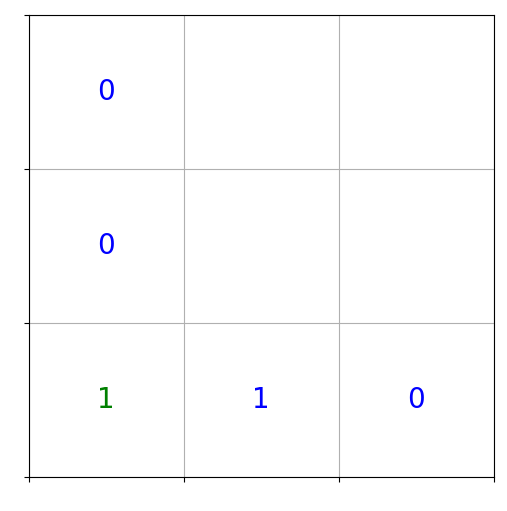

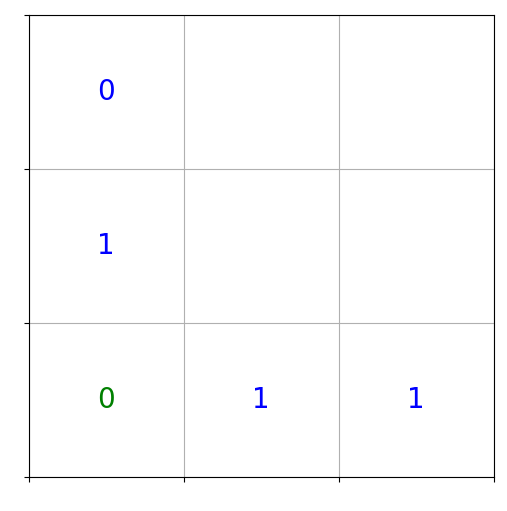

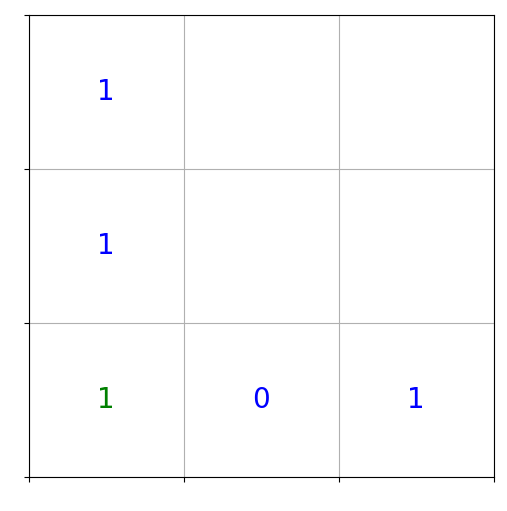

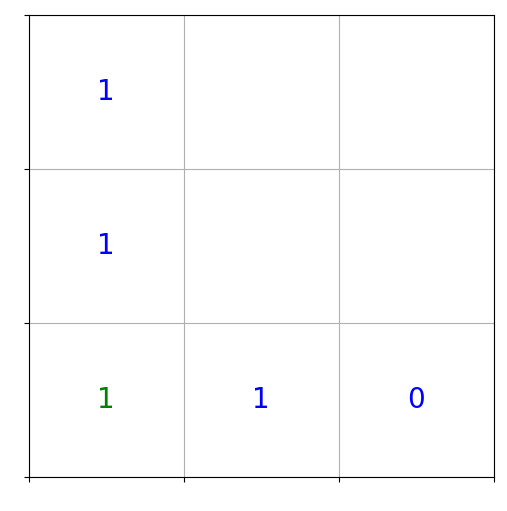

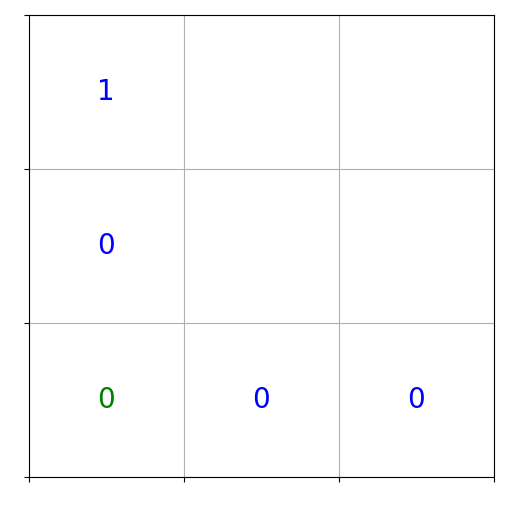

Results for (2, 1):


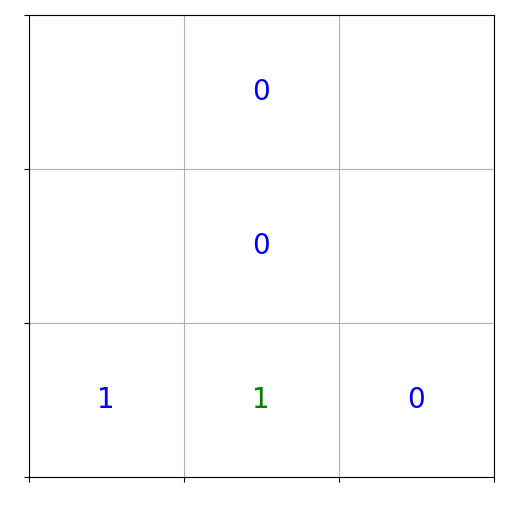

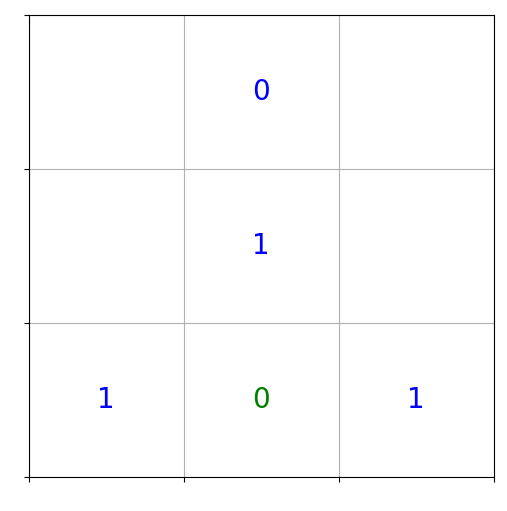

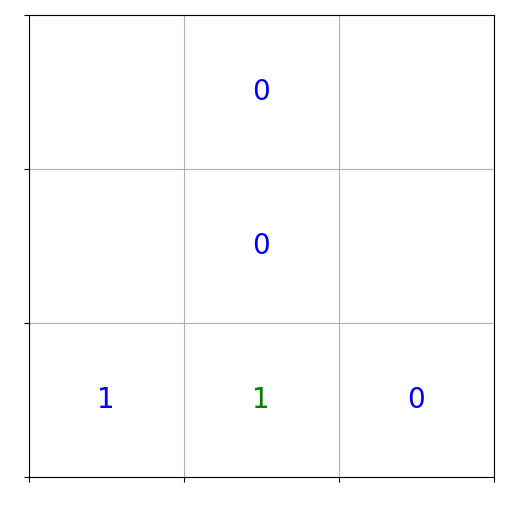

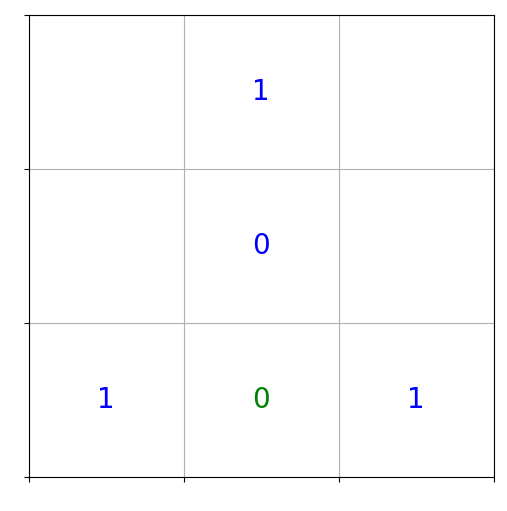

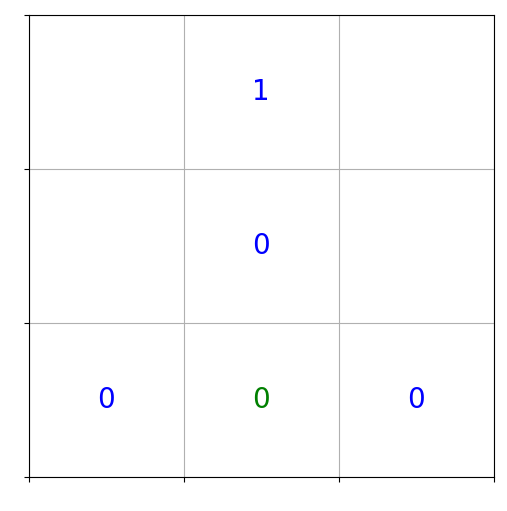

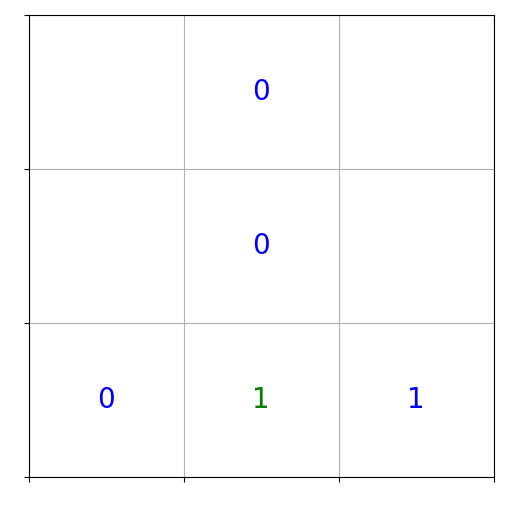

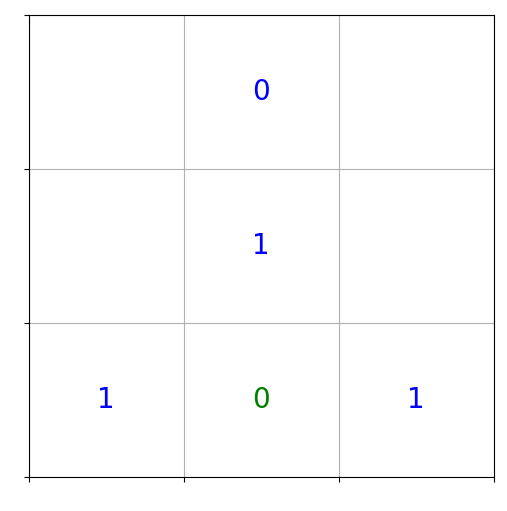

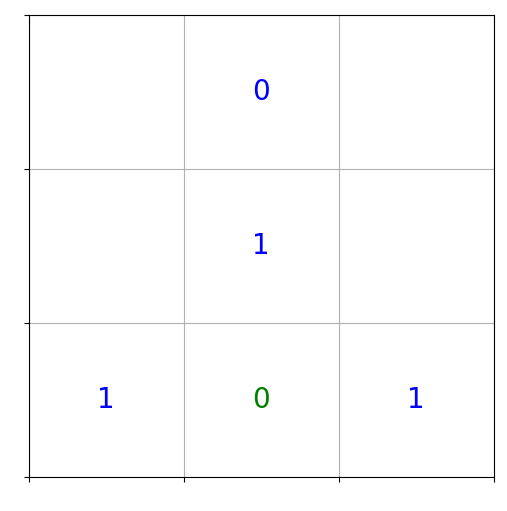

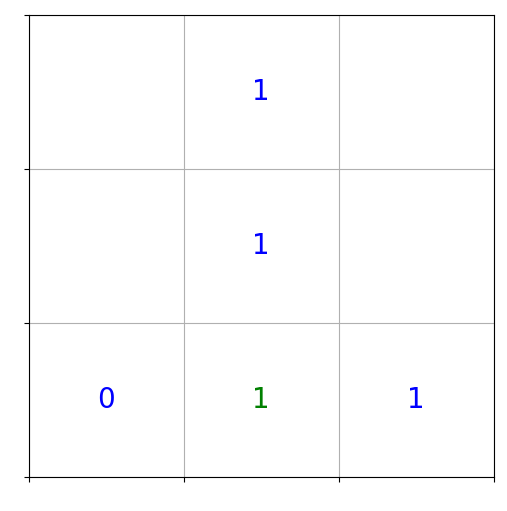

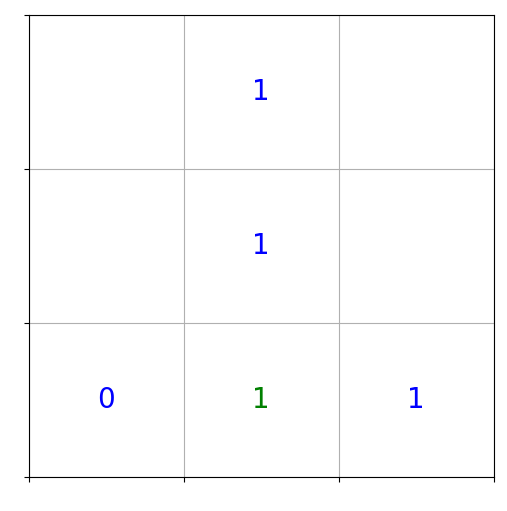

Results for (2, 2):


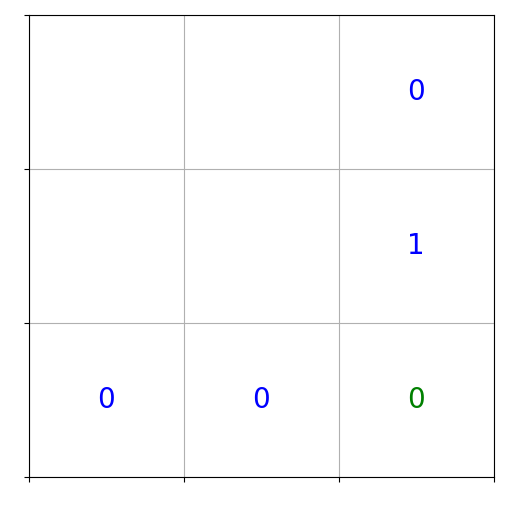

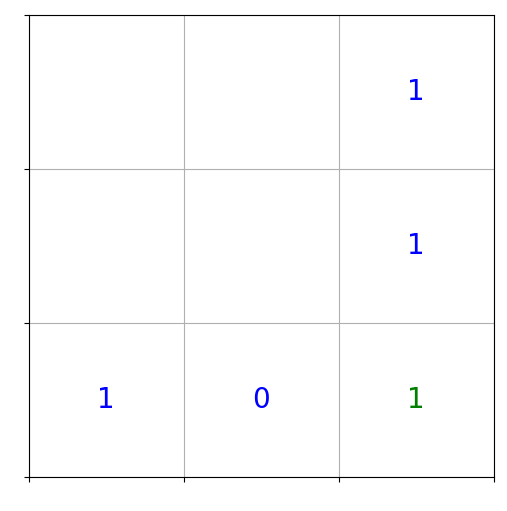

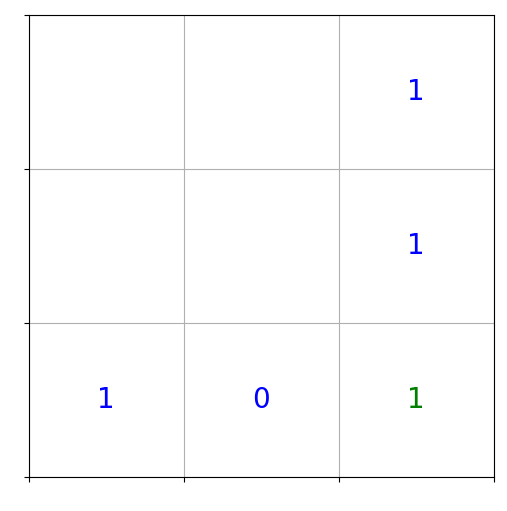

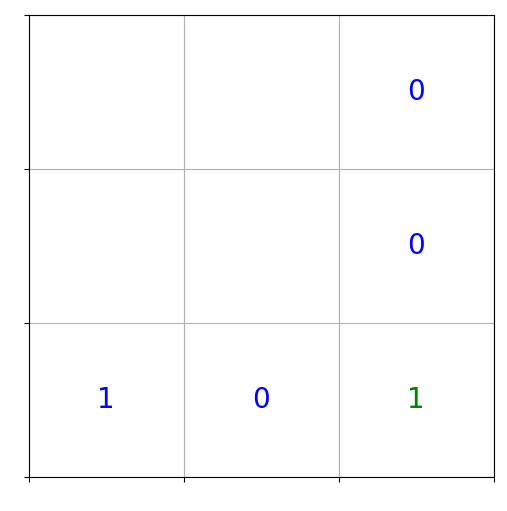

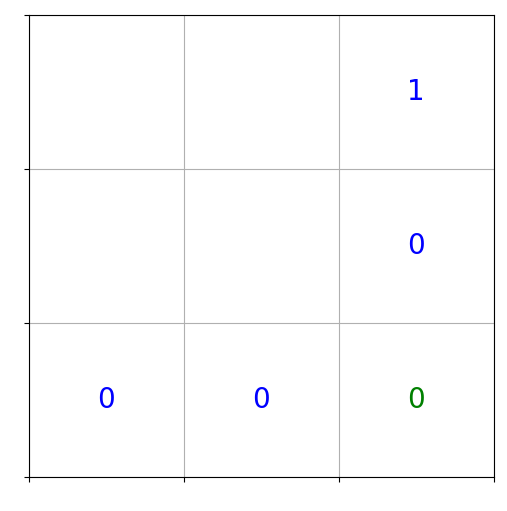

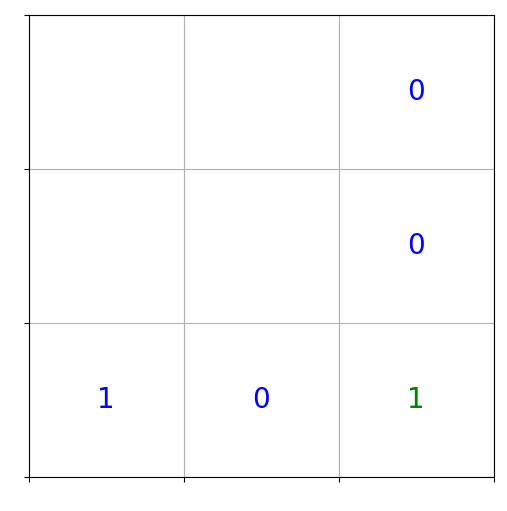

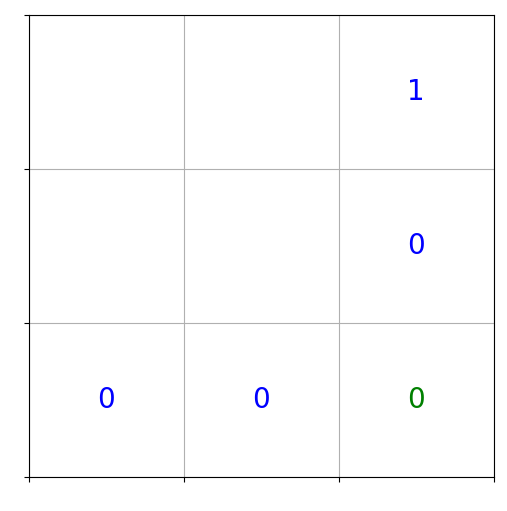

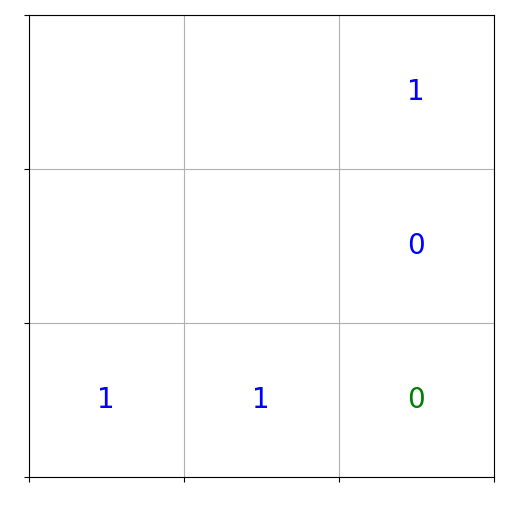

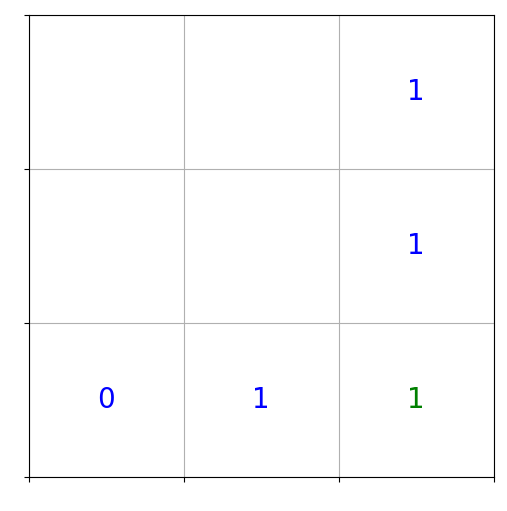

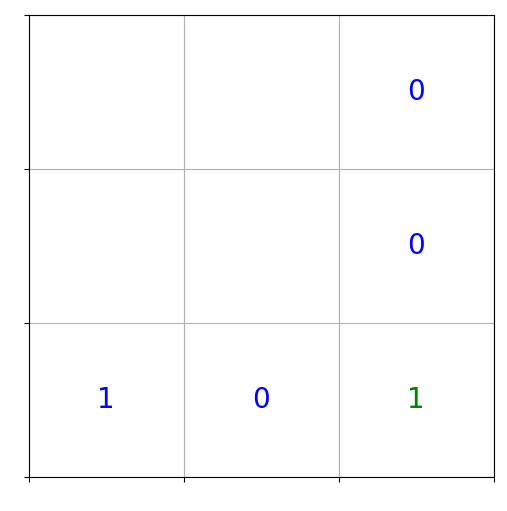

In [38]:
for (row, col), results in results_dict.items():
    print(f"Results for ({row}, {col}):")
    for alice_bit, bob_bit in results:
        magic_square_visualization(alice_bit, bob_bit, int(row), int(col))

In [41]:
quantum_win_probability = sum(magic_square_score(alice_bit, bob_bit, int(row), int(col)) for (row, col), results in results_dict.items() for alice_bit, bob_bit in results) / (len(results_dict) * total_trials)
print(f"Quantum Win Probability: {quantum_win_probability:.2f}")

Quantum Win Probability: 1.00
